# Predicting Early Cognitive Impairment Using MRI and Biologically-Guided Feature Engineering
## 2025 Fall DS9000: Introduction To Machine Learning

#### Arshya Pooladi-Darvish
#### David Wu
#### Victor Lau

Our project intends to address a research gap: screening cognitive impairment may be better selected via improved selection of brain regions that are specifically involved in mild cognitive impairment (MCI) and Alzheimer's disease (AD). Our project intends to leverage this gap by using biologically relevant feature engineering to train ML models and classify earlier cognitive impairment (for AD risk).

Our open-access datasets are derived from OASIS-1 (https://www.kaggle.com/datasets/ninadaithal/oasis-1-shinohara/data, or alternatively https://sites.wustl.edu/oasisbrains/). We later also added in data processed at https://www.biorxiv.org/content/10.1101/2025.10.15.682705v1.full , adapted from https://adni.loni.usc.edu/data-samples/adni-data/neuroimaging/mri/), with adjustments to our ML model feature extraction to account for dataset differences. 

This notebook is intended to provide the code and ML model performances. It will be uploaded on github, alongside our spreadsheets (tsv/csv) to provide reproducibility.

In [5]:
#Install required packages if needed (recommended to run in a virtual environment, venv)

# !python -m pip install pandas
# !python -m pip install numpy
# !python -m pip install matplotlib
# !python -m pip install seaborn
# !python -m pip install scikit-learn
# !python -m pip install xgboost
# !python -m pip install statsmodels

# PyTorch (CPU version):
# !python -m pip install torch --index-url https://download.pytorch.org/whl/cpu

# Or one-line:
# !python -m pip install pandas numpy matplotlib seaborn scikit-learn xgboost

#### Data Loading

In [6]:
import pandas as pd
mri_df = pd.read_csv('oasis_roi_volumes.tsv', sep='\t')
adni_df = pd.read_csv('baseline_data.csv')
adni_df.head()

,ID,M/F,Age,CDR,nWBV,L_Hippocampus_L_Ventricle_Ratio,L_Entorhinal_L_Ventricle_Ratio,R_Hippocampus_R_Ventricle_Ratio,R_Entorhinal_R_Ventricle_Ratio,Lateral_Ventricle_Volume
0,sub-ADNI002S0413,F,76.3,0.0,0.793591,0.202188,0.236319,0.163105,0.210202,0.027502
1,sub-ADNI002S1155,M,57.8,0.7,0.791117,0.157858,0.176767,0.137125,0.166139,0.033862
2,sub-ADNI002S1261,F,71.1,0.0,0.769045,0.119342,0.161956,0.092490,0.149365,0.037475
3,sub-ADNI002S1280,F,70.7,0.0,0.772878,0.228979,0.268187,0.238436,0.299458,0.021656
4,sub-ADNI002S4213,F,78.0,0.0,0.772387,0.192671,0.199721,0.170355,0.197699,0.029748


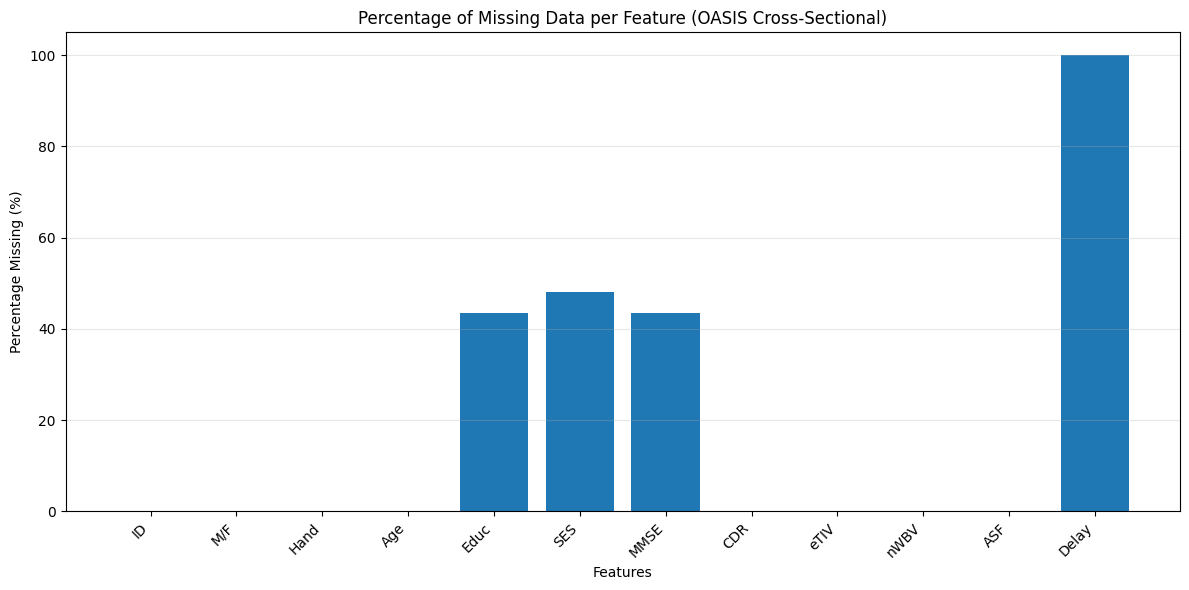

Missing data summary:
Delay    100.000000
SES       48.076923
Educ      43.509615
MMSE      43.509615
dtype: float64


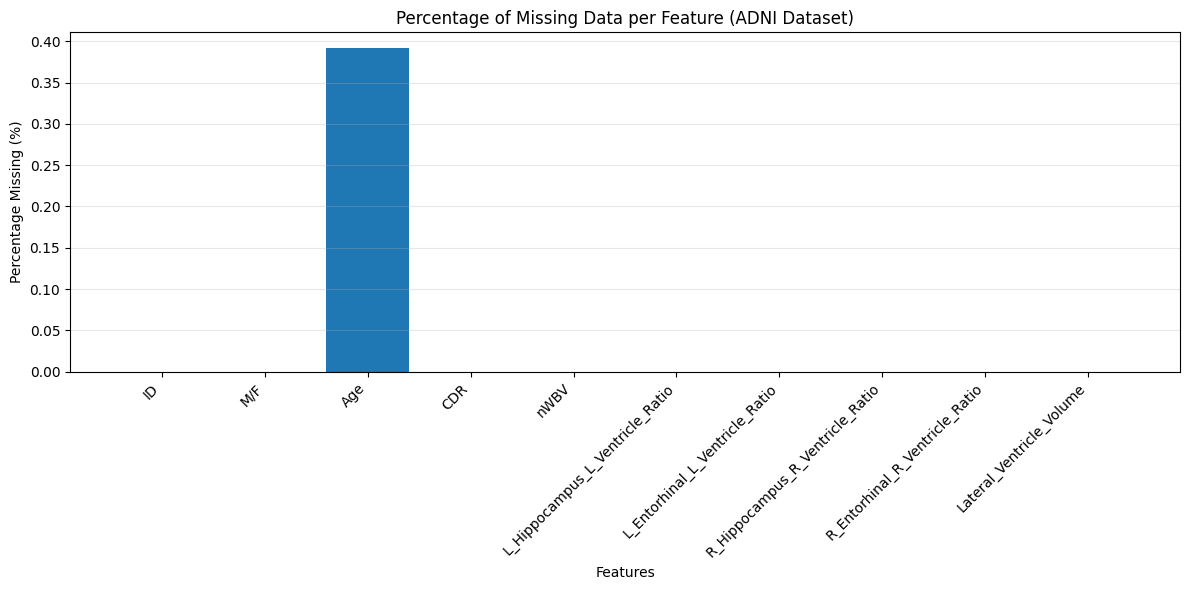

Missing data summary:
Age    0.391134
dtype: float64

Total subjects: 767
Final shape: (405, 15)

Columns: ['ID', 'M/F', 'Age', 'CDR', 'nWBV', 'lh_lateral_ventricle', 'rh_lateral_ventricle', 'lh_hippocampus', 'rh_hippocampus', 'lh_entorhinal', 'rh_entorhinal', 'lh_parahippocampal', 'rh_parahippocampal', 'lh_thalamus', 'rh_thalamus']

First few rows:


,ID,M/F,Age,CDR,nWBV,lh_lateral_ventricle,rh_lateral_ventricle,lh_hippocampus,rh_hippocampus,lh_entorhinal,rh_entorhinal,lh_parahippocampal,rh_parahippocampal,lh_thalamus,rh_thalamus
0,OAS1_0001_MR1,F,74,0.0,0.743,36366.876,30115.054,4576.224,5099.930,1205.438,1021.292,1341.262,1548.916,6989.712,7210.426
1,OAS1_0002_MR1,F,55,0.0,0.810,4974.219,4706.294,5794.835,6560.335,1704.003,1549.372,2224.543,2804.792,8497.050,8659.336
2,OAS1_0003_MR1,F,73,0.5,0.708,27258.888,24119.481,3373.565,3489.437,806.276,554.013,1513.578,1442.365,6870.244,6858.174
3,OAS1_0004_MR1,M,28,0.0,0.803,17859.010,13059.995,4341.545,4681.885,1149.200,1635.400,1666.340,1934.855,7509.580,7444.385
4,OAS1_0005_MR1,M,18,0.0,0.848,4837.900,4266.240,4929.810,4736.900,1591.760,1215.030,2331.080,2015.960,7906.280,7565.910


In [7]:
import matplotlib.pyplot as plt
df = pd.read_csv('oasis_cross-sectional.csv')

# Drop any rows with _MR2 in ID column (keep only baseline scans)
df = df[~df['ID'].str.contains('_MR2', na=False)]

missing_pct = (df.isnull().sum() / len(df)) * 100

# Create bar plot
plt.figure(figsize=(12, 6))
plt.bar(range(len(missing_pct)), missing_pct.values)
plt.xticks(range(len(missing_pct)), missing_pct.index, rotation=45, ha='right')
plt.ylabel('Percentage Missing (%)')
plt.xlabel('Features')
plt.title('Percentage of Missing Data per Feature (OASIS Cross-Sectional)')
plt.tight_layout()
plt.grid(axis='y', alpha=0.3)
plt.show()
print("Missing data summary:")
print(missing_pct[missing_pct > 0].sort_values(ascending=False))


missing_pct = (adni_df.isnull().sum() / len(adni_df)) * 100

# Create bar plot
plt.figure(figsize=(12, 6))
plt.bar(range(len(missing_pct)), missing_pct.values)
plt.xticks(range(len(missing_pct)), missing_pct.index, rotation=45, ha='right')
plt.ylabel('Percentage Missing (%)')
plt.xlabel('Features')
plt.title('Percentage of Missing Data per Feature (ADNI Dataset)')
plt.tight_layout()
plt.grid(axis='y', alpha=0.3)
plt.show()

print("Missing data summary:")
print(missing_pct[missing_pct > 0].sort_values(ascending=False))
print(f"\nTotal subjects: {len(adni_df)}")

# Drop specified columns
df = df.drop(columns=['Educ', 'SES', 'MMSE', 'eTIV', 'Delay','Hand'])

# Load MRI volumes
mri_df = pd.read_csv('oasis_roi_volumes.tsv', sep='\t')

# Merge the dataframes on subject ID
df = df.merge(mri_df, left_on='ID', right_on='subject_id', how='inner')

# Drop the redundant subject_id column from mri_df
df = df.drop(columns=['subject_id'])

# Get all columns that contain 'lh_' or 'rh_' (ROI volumes)
roi_columns = [col for col in df.columns if 'lh_' in col or 'rh_' in col]

# Scale ROI volumes by ASF for each subject
for col in roi_columns:
    df[col] = df[col] * df['ASF']

# Drop ASF column after scaling
df = df.drop(columns=['ASF'])

print(f"Final shape: {df.shape}")
print(f"\nColumns: {list(df.columns)}")
print(f"\nFirst few rows:")
df.head()

In [8]:
df = pd.read_csv('oasis_cross-sectional.csv')
df = df[~df['ID'].str.contains('_MR2', na=False)]

# Drop specified columns
df = df.drop(columns=['Educ', 'SES', 'MMSE', 'eTIV', 'Delay','Hand'])

# Load MRI volumes
mri_df = pd.read_csv('oasis_roi_volumes.tsv', sep='\t')

# Merge the dataframes on subject ID
df = df.merge(mri_df, left_on='ID', right_on='subject_id', how='inner')

# Drop the redundant subject_id column from mri_df
df = df.drop(columns=['subject_id'])

# Get all columns that contain 'lh_' or 'rh_' (ROI volumes)
roi_columns = [col for col in df.columns if 'lh_' in col or 'rh_' in col]

# Scale ROI volumes by ASF for each subject
for col in roi_columns:
    df[col] = df[col] * df['ASF']

# Drop ASF column after scaling
df = df.drop(columns=['ASF'])

print(f"Original shape: {df.shape}")

# Create new dataframe with engineered ratio features
new_df = pd.DataFrame()
new_df['ID'] = df['ID']
new_df['M/F'] = df['M/F']
new_df['Age'] = df['Age']
new_df['CDR'] = df['CDR']
new_df['nWBV'] = df['nWBV']

# Create ratio features
new_df['L_Hippocampus_L_Ventricle_Ratio'] = df['lh_hippocampus'] / df['lh_lateral_ventricle']
# new_df['L_Parahippocampal_L_Ventricle_Ratio'] = df['lh_parahippocampal'] / df['lh_lateral_ventricle']
new_df['L_Entorhinal_L_Ventricle_Ratio'] = df['lh_entorhinal'] / df['lh_lateral_ventricle']
new_df['R_Hippocampus_R_Ventricle_Ratio'] = df['rh_hippocampus'] / df['rh_lateral_ventricle']
# new_df['R_Parahippocampal_R_Ventricle_Ratio'] = df['rh_parahippocampal'] / df['rh_lateral_ventricle']
new_df['R_Entorhinal_R_Ventricle_Ratio'] = df['rh_entorhinal'] / df['rh_lateral_ventricle']
new_df['Lateral_Ventricle_Volume'] = (df['lh_lateral_ventricle'] + df['rh_lateral_ventricle'])
# new_df['L_MTL_volume'] = (df['lh_hippocampus'] + df['lh_entorhinal']) / df['lh_lateral_ventricle']  # Assuming MTL volume is sum of hippocampus and entorhinal volumes on left side
# new_df['R_MTL_volume'] = (df['rh_hippocampus'] + df['rh_entorhinal']) / df['rh_lateral_ventricle']  # Assuming MTL volume is sum of hippocampus and entorhinal volumes on right side

new_df = pd.concat([new_df, adni_df], axis=0, ignore_index=True)
# 3 Rows dont have any age.. dropping these
new_df = new_df.dropna(how='any')
print(f"New shape: {new_df.shape}")
print(f"\nColumns: {list(new_df.columns)}")
print(f"\nFirst few rows:")
# Print number of CDR=0 and CDR>0
print(f"CDR=0 count: {new_df[new_df['CDR'] == 0].shape[0]}")
print(f"CDR>0 count: {new_df[new_df['CDR'] > 0].shape[0]}")

# 3 Rows dont have any age.. dropping these
new_df = new_df.dropna(how='any')

Original shape: (405, 15)
New shape: (1169, 10)

Columns: ['ID', 'M/F', 'Age', 'CDR', 'nWBV', 'L_Hippocampus_L_Ventricle_Ratio', 'L_Entorhinal_L_Ventricle_Ratio', 'R_Hippocampus_R_Ventricle_Ratio', 'R_Entorhinal_R_Ventricle_Ratio', 'Lateral_Ventricle_Volume']

First few rows:
CDR=0 count: 725
CDR>0 count: 444


In [9]:
from scipy import stats
import pandas as pd
import numpy as np
from statsmodels.stats.multitest import multipletests

cdr0 = new_df[new_df['CDR'] == 0]
cdr_pos = new_df[new_df['CDR'] > 0]

results = []
p_values = []

for col in ['L_Hippocampus_L_Ventricle_Ratio', 'L_Entorhinal_L_Ventricle_Ratio', 
            'nWBV', 'Age', 'R_Entorhinal_R_Ventricle_Ratio', 
            'R_Hippocampus_R_Ventricle_Ratio', 'Lateral_Ventricle_Volume']:
    
    stat, p_val = stats.ttest_ind(cdr0[col], cdr_pos[col])
    p_values.append(p_val)
    
    mean_cdr0 = cdr0[col].mean()
    mean_cdr_pos = cdr_pos[col].mean()
    
    results.append({
        'Variable': col,
        'p': p_val,
        'CDR=0': mean_cdr0,
        'CDR>0': mean_cdr_pos
    })

sex_contingency = pd.crosstab(new_df['CDR'] == 0, new_df['M/F'])
chi2, p_sex, dof, expected = stats.chi2_contingency(sex_contingency)
p_values.append(p_sex)

results.append({
    'Variable': 'Sex (M/F)',
    'p': p_sex,
    'CDR=0': f"{cdr0[cdr0['M/F']=='M'].shape[0]}/{cdr0[cdr0['M/F']=='F'].shape[0]}",
    'CDR>0': f"{cdr_pos[cdr_pos['M/F']=='M'].shape[0]}/{cdr_pos[cdr_pos['M/F']=='F'].shape[0]}"
})

reject, fdr_corrected, _, _ = multipletests(p_values, method='fdr_bh')

for i, res in enumerate(results):
    res['FDR'] = fdr_corrected[i]

table1 = pd.DataFrame(results)

for col in ['p', 'FDR']:
    table1[col] = table1[col].apply(lambda x: f"{x:.2e}" if isinstance(x, (int, float)) else x)

for col in ['CDR=0', 'CDR>0']:
    table1[col] = table1[col].apply(lambda x: f"{x:.3f}" if isinstance(x, (int, float)) else x)

print("\nTABLE 1")
print("GROUP MEAN DIFFERENCES BETWEEN CDR = 0 AND CDR > 0\n")
print(table1.to_string(index=False))


TABLE 1
GROUP MEAN DIFFERENCES BETWEEN CDR = 0 AND CDR > 0

                       Variable        p     CDR=0     CDR>0      FDR
L_Hippocampus_L_Ventricle_Ratio 5.91e-42     0.431     0.204 2.36e-41
 L_Entorhinal_L_Ventricle_Ratio 9.99e-12     0.261     0.193 1.60e-11
                           nWBV 3.85e-45     0.801     0.768 3.08e-44
                            Age 3.90e-35    59.765    72.897 7.81e-35
 R_Entorhinal_R_Ventricle_Ratio 3.23e-06     0.256     0.210 4.31e-06
R_Hippocampus_R_Ventricle_Ratio 9.82e-42     0.461     0.213 2.62e-41
       Lateral_Ventricle_Volume 5.55e-01 10225.080 10913.784 5.55e-01
                      Sex (M/F) 2.39e-05   289/436   234/210 2.73e-05


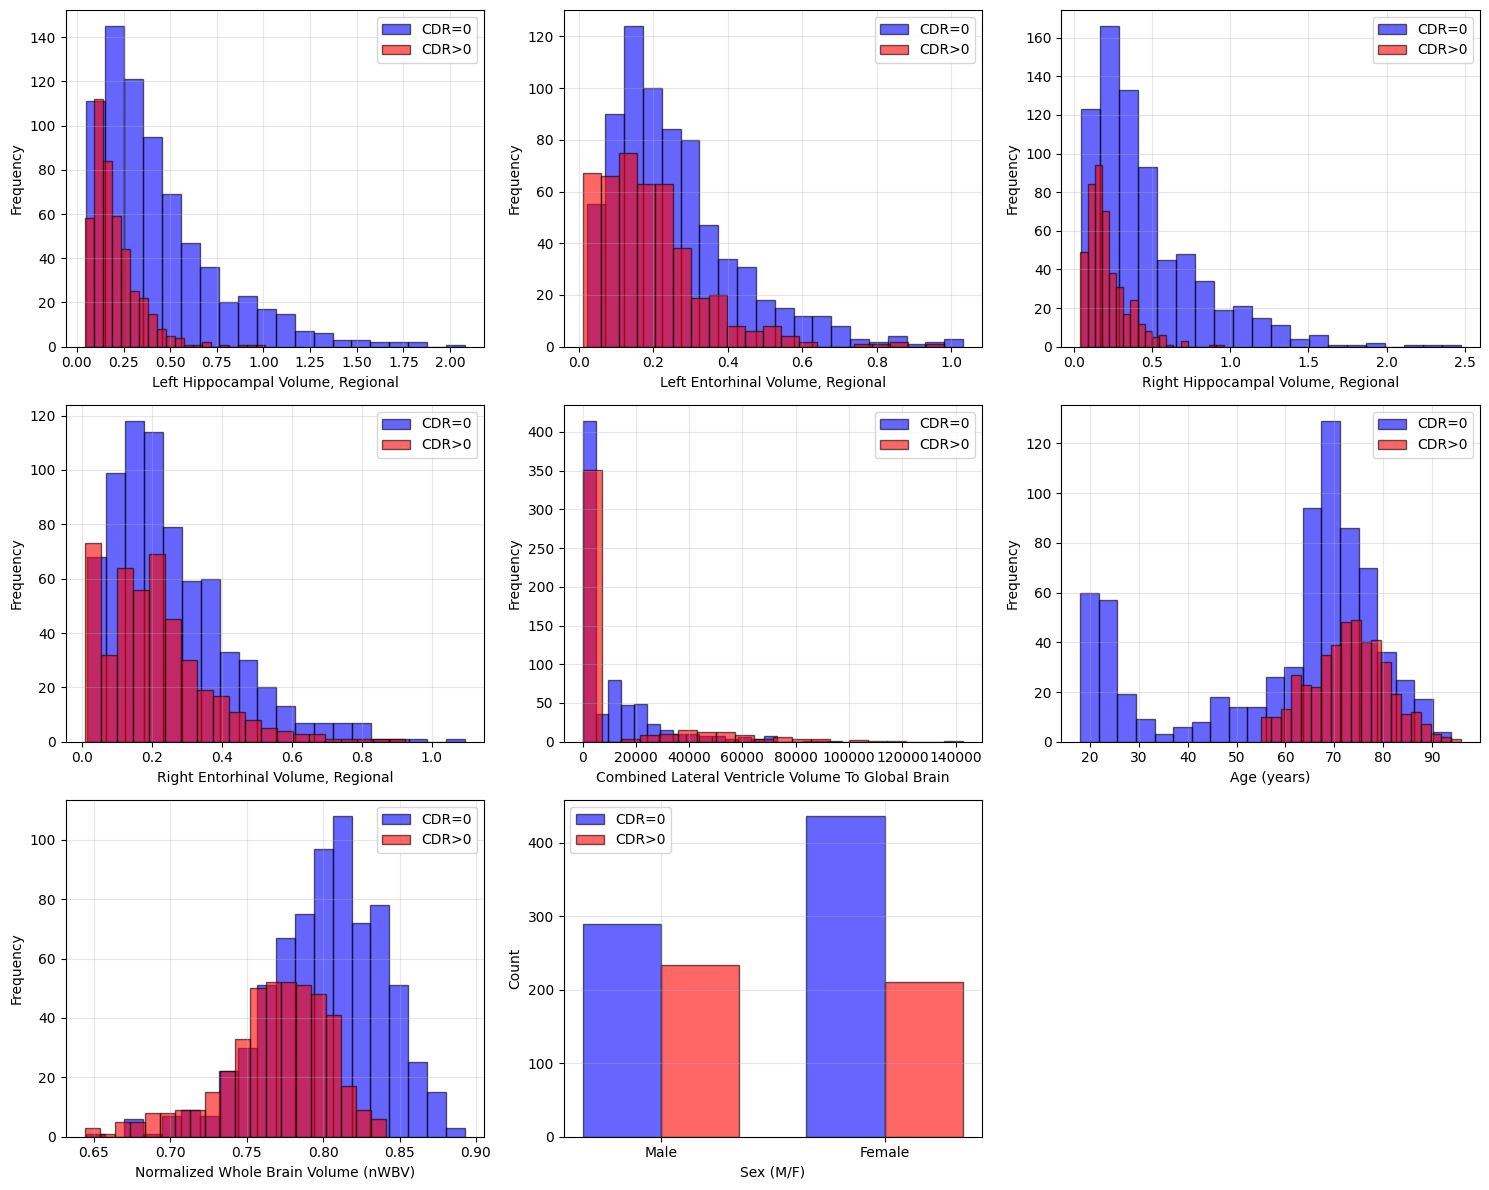

In [10]:
import matplotlib.pyplot as plt
import numpy as np

pretty_map = {
    'L_Hippocampus_L_Ventricle_Ratio': 'Left Hippocampal Volume, Regional',
    'L_Entorhinal_L_Ventricle_Ratio': 'Left Entorhinal Volume, Regional',
    'R_Hippocampus_R_Ventricle_Ratio': 'Right Hippocampal Volume, Regional',
    'R_Entorhinal_R_Ventricle_Ratio': 'Right Entorhinal Volume, Regional',
    'Lateral_Ventricle_Volume': 'Combined Lateral Ventricle Volume To Global Brain',
    'Age': 'Age (years)',
    'nWBV': 'Normalized Whole Brain Volume (nWBV)',
    'M/F': 'Sex (M/F)'
}

cdr0 = new_df[new_df['CDR'] == 0]
cdr_pos = new_df[new_df['CDR'] > 0]

continuous_features = ['L_Hippocampus_L_Ventricle_Ratio', 'L_Entorhinal_L_Ventricle_Ratio',
                       'R_Hippocampus_R_Ventricle_Ratio', 'R_Entorhinal_R_Ventricle_Ratio',
                       'Lateral_Ventricle_Volume', 'Age', 'nWBV']

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for idx, feature in enumerate(continuous_features):
    ax = axes[idx]
    ax.hist(cdr0[feature], bins=20, alpha=0.6, label='CDR=0', color='blue', edgecolor='black')
    ax.hist(cdr_pos[feature], bins=20, alpha=0.6, label='CDR>0', color='red', edgecolor='black')
    ax.set_xlabel(pretty_map[feature])
    ax.set_ylabel('Frequency')
    ax.legend()
    ax.grid(alpha=0.3)

ax = axes[7]
sex_data = pd.DataFrame({
    'CDR=0 Male': [cdr0[cdr0['M/F']=='M'].shape[0]],
    'CDR=0 Female': [cdr0[cdr0['M/F']=='F'].shape[0]],
    'CDR>0 Male': [cdr_pos[cdr_pos['M/F']=='M'].shape[0]],
    'CDR>0 Female': [cdr_pos[cdr_pos['M/F']=='F'].shape[0]]
})
x = np.arange(2)
width = 0.35
ax.bar(x - width/2, [sex_data['CDR=0 Male'][0], sex_data['CDR=0 Female'][0]], width, label='CDR=0', color='blue', alpha=0.6, edgecolor='black')
ax.bar(x + width/2, [sex_data['CDR>0 Male'][0], sex_data['CDR>0 Female'][0]], width, label='CDR>0', color='red', alpha=0.6, edgecolor='black')
ax.set_xlabel(pretty_map['M/F'])
ax.set_ylabel('Count')
ax.set_xticks(x)
ax.set_xticklabels(['Male', 'Female'])
ax.legend()
ax.grid(alpha=0.3)

axes[8].axis('off')

plt.tight_layout()
plt.show()

## Logistic Regression

Class distribution:
CDR_binary
0    725
1    444
Name: count, dtype: int64

Class proportions:
CDR_binary
0    0.620188
1    0.379812
Name: proportion, dtype: float64

Held-out test set size: 234
Test CDR=0: 145, CDR>0: 89

NESTED CROSS-VALIDATION (5 outer folds, 3 inner folds)
Optimizing for Macro F1 score

--- Outer Fold 1/5 ---
Best params: {'C': 1.0, 'penalty': 'l2', 'solver': 'lbfgs'}
Best Macro F1 score (inner CV): 0.679
Validation Accuracy: 0.674
Validation Macro F1: 0.673
Validation AUC: 0.767
Confusion Matrix:
[[68 48]
 [13 58]]

--- Outer Fold 2/5 ---
Best params: {'C': 1.0, 'penalty': 'l2', 'solver': 'lbfgs'}
Best Macro F1 score (inner CV): 0.675
Validation Accuracy: 0.663
Validation Macro F1: 0.661
Validation AUC: 0.760
Confusion Matrix:
[[70 46]
 [17 54]]

--- Outer Fold 3/5 ---
Best params: {'C': 10.0, 'penalty': 'l2', 'solver': 'lbfgs'}
Best Macro F1 score (inner CV): 0.680
Validation Accuracy: 0.674
Validation Macro F1: 0.670
Validation AUC: 0.759
Confusion Matrix:
[[73

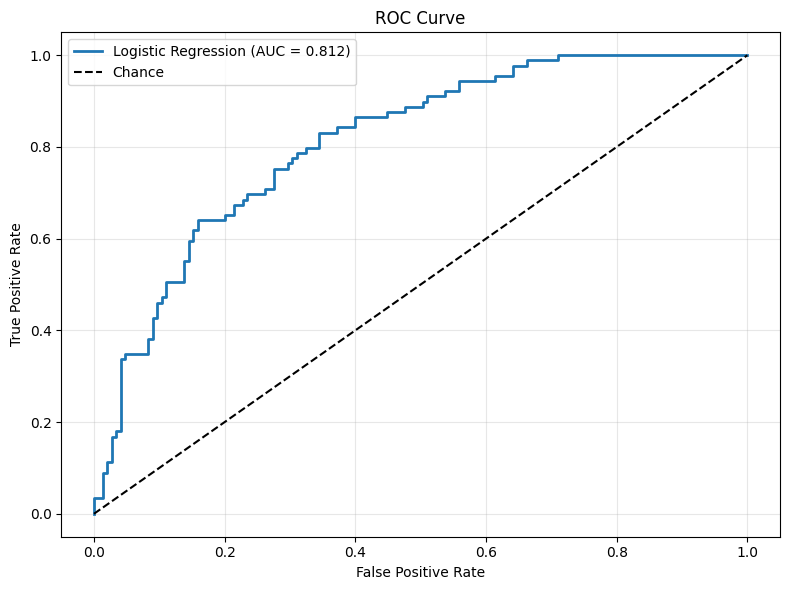

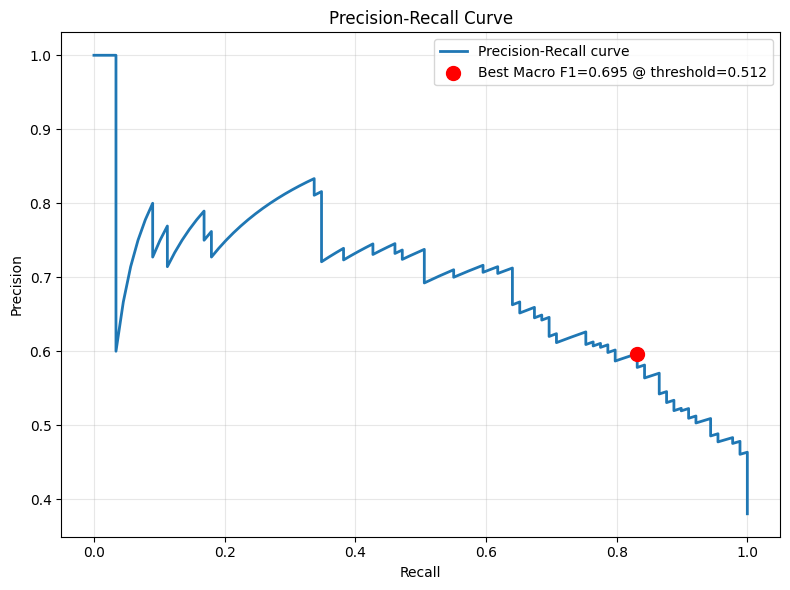

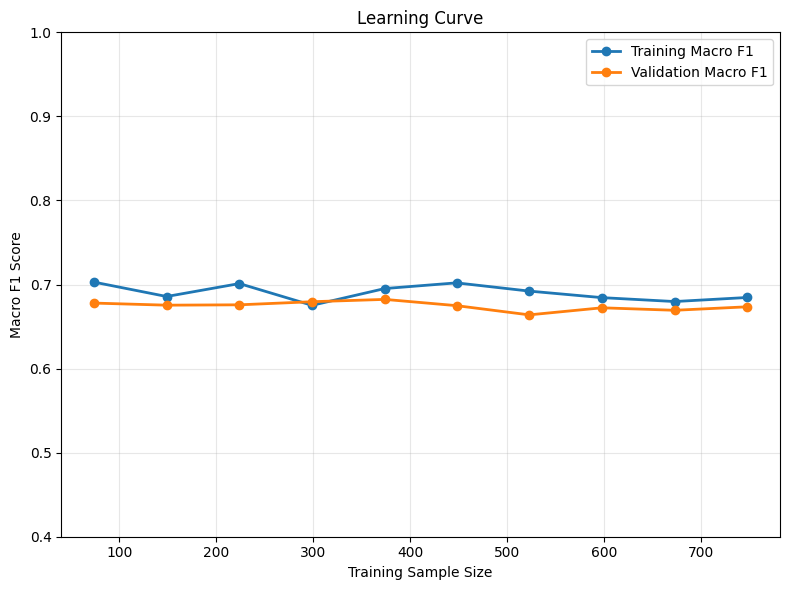

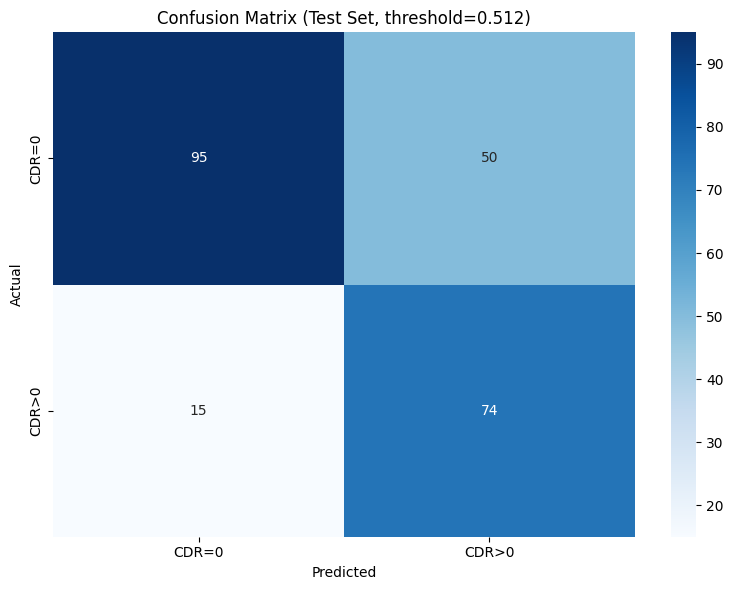


MODEL COEFFICIENTS

All 8 features ranked by |coefficient|:
1. L_Hippocampus_L_Ventricle_Ratio: -0.9661
2. R_Hippocampus_R_Ventricle_Ratio: -0.7435
3. nWBV: -0.7027
4. R_Entorhinal_R_Ventricle_Ratio: 0.6303
5. Lateral_Ventricle_Volume: -0.0567
6. M/F: 0.0551
7. L_Entorhinal_L_Ventricle_Ratio: 0.0180
8. Age: 0.0143


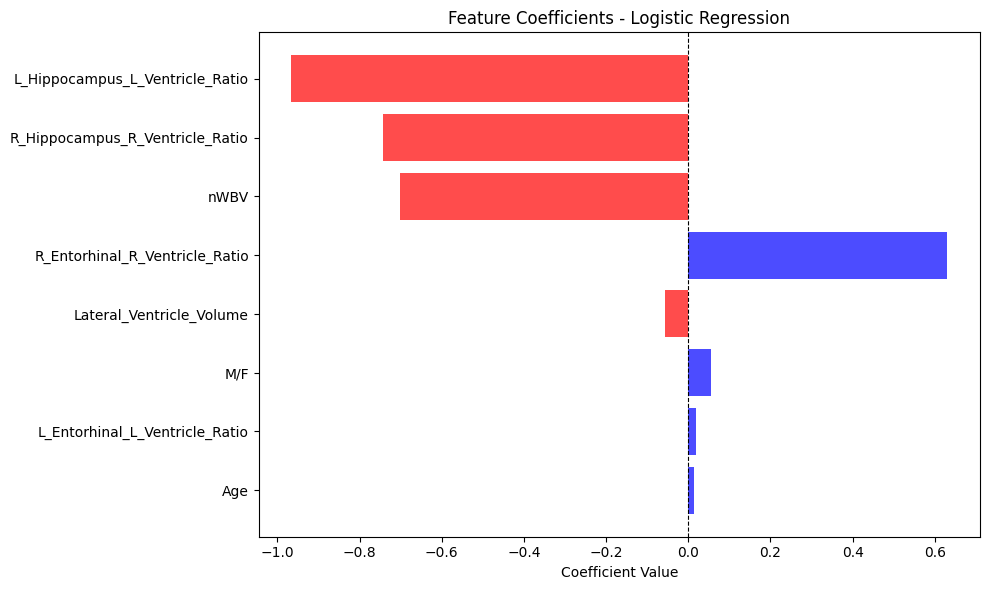


FINAL SUMMARY

Nested CV estimate (unbiased): 0.674 ± 0.015
Test set performance: Macro F1=0.720, AUC=0.812


In [11]:
import numpy as np
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split, learning_curve
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report, cohen_kappa_score, roc_auc_score, roc_curve, precision_recall_curve
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

new_df['CDR_binary'] = (new_df['CDR'] > 0).astype(int)

print("Class distribution:")
print(new_df['CDR_binary'].value_counts())
print(f"\nClass proportions:")
print(new_df['CDR_binary'].value_counts(normalize=True))

X = new_df.drop(columns=['ID', 'CDR', 'CDR_binary'])

X['M/F'] = (X['M/F'] == 'M').astype(int)

y = new_df['CDR_binary']

X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nHeld-out test set size: {len(X_test)}")
print(f"Test CDR=0: {sum(y_test==0)}, CDR>0: {sum(y_test==1)}")

outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
inner_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

param_grid = {
    'C': [0.001, 0.01, 0.1, 1.0, 10.0, 100.0],
    'penalty': ['l2'],
    'solver': ['lbfgs']
}

outer_scores_acc = []
outer_scores_f1_macro = []
outer_scores_auc = []
best_params_list = []

print("\n" + "="*70)
print("NESTED CROSS-VALIDATION (5 outer folds, 3 inner folds)")
print("Optimizing for Macro F1 score")
print("="*70)

for fold_idx, (train_idx, val_idx) in enumerate(outer_cv.split(X_train_full, y_train_full), 1):
    print(f"\n--- Outer Fold {fold_idx}/5 ---")
    
    X_train_fold = X_train_full.iloc[train_idx]
    X_val_fold = X_train_full.iloc[val_idx]
    y_train_fold = y_train_full.iloc[train_idx]
    y_val_fold = y_train_full.iloc[val_idx]
    
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_fold)
    X_val_scaled = scaler.transform(X_val_fold)
    
    grid_search = GridSearchCV(
        LogisticRegression(class_weight='balanced', max_iter=10000, random_state=42),
        param_grid=param_grid,
        cv=inner_cv,
        scoring='f1_macro',
        n_jobs=-1,
        verbose=0
    )
    
    grid_search.fit(X_train_scaled, y_train_fold)
    
    best_model = grid_search.best_estimator_
    best_params_list.append(grid_search.best_params_)
    
    print(f"Best params: {grid_search.best_params_}")
    print(f"Best Macro F1 score (inner CV): {grid_search.best_score_:.3f}")
    
    y_val_pred = best_model.predict(X_val_scaled)
    y_val_proba = best_model.predict_proba(X_val_scaled)[:, 1]
    
    fold_acc = accuracy_score(y_val_fold, y_val_pred)
    fold_f1_macro = f1_score(y_val_fold, y_val_pred, average='macro')
    fold_auc = roc_auc_score(y_val_fold, y_val_proba)
    
    outer_scores_acc.append(fold_acc)
    outer_scores_f1_macro.append(fold_f1_macro)
    outer_scores_auc.append(fold_auc)
    
    print(f"Validation Accuracy: {fold_acc:.3f}")
    print(f"Validation Macro F1: {fold_f1_macro:.3f}")
    print(f"Validation AUC: {fold_auc:.3f}")
    print(f"Confusion Matrix:")
    print(confusion_matrix(y_val_fold, y_val_pred))

print("\n" + "="*70)
print("NESTED CV SUMMARY")
print("="*70)
print(f"Mean Macro F1 across folds: {np.mean(outer_scores_f1_macro):.3f} ± {np.std(outer_scores_f1_macro):.3f}")
print(f"Macro F1 per fold: {[f'{s:.3f}' for s in outer_scores_f1_macro]}")
print(f"\nMean AUC across folds: {np.mean(outer_scores_auc):.3f} ± {np.std(outer_scores_auc):.3f}")
print(f"AUC per fold: {[f'{s:.3f}' for s in outer_scores_auc]}")
print(f"\nMean Accuracy across folds: {np.mean(outer_scores_acc):.3f} ± {np.std(outer_scores_acc):.3f}")

print(f"\nMost common best params:")
for param in ['C', 'penalty', 'solver']:
    values = [p[param] for p in best_params_list]
    most_common = Counter(values).most_common(1)[0]
    print(f"  {param}: {most_common[0]} (appeared {most_common[1]}/5 folds)")

print("\n" + "="*70)
print("FINAL MODEL ON HELD-OUT TEST SET")
print("="*70)

final_C = Counter([p['C'] for p in best_params_list]).most_common(1)[0][0]
print(f"Using C: {final_C}")

scaler_final = StandardScaler()
X_train_scaled_final = scaler_final.fit_transform(X_train_full)
X_test_scaled_final = scaler_final.transform(X_test)

final_lr = LogisticRegression(
    C=final_C,
    class_weight='balanced',
    max_iter=1000,
    random_state=42
)
final_lr.fit(X_train_scaled_final, y_train_full)

y_test_proba = final_lr.predict_proba(X_test_scaled_final)[:, 1]

precision, recall, thresholds_pr = precision_recall_curve(y_test, y_test_proba)
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-10)
best_f1_idx = np.argmax(f1_scores)
best_threshold = thresholds_pr[best_f1_idx]

print(f"\nOptimal threshold for Macro F1: {best_threshold:.3f}")

y_test_pred = (y_test_proba >= best_threshold).astype(int)

test_acc = accuracy_score(y_test, y_test_pred)
test_f1_macro = f1_score(y_test, y_test_pred, average='macro')
test_auc = roc_auc_score(y_test, y_test_proba)

print(f"\nTest Set Performance:")
print(f"Accuracy: {test_acc:.3f}")
print(f"Macro F1 Score: {test_f1_macro:.3f}")
print(f"AUC-ROC: {test_auc:.3f}")

print(f"\nClassification Report:")
print(classification_report(y_test, y_test_pred, target_names=['CDR=0', 'CDR>0']))

print(f"\nConfusion Matrix (Test):")
print(confusion_matrix(y_test, y_test_pred))

fpr, tpr, thresholds_roc = roc_curve(y_test, y_test_proba)
best_threshold_idx = np.argmin(np.abs(thresholds_roc - best_threshold))
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'Logistic Regression (AUC = {test_auc:.3f})', linewidth=2)
plt.plot([0, 1], [0, 1], 'k--', label='Chance')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 6))
plt.plot(recall, precision, linewidth=2, label='Precision-Recall curve')
plt.scatter(recall[best_f1_idx], precision[best_f1_idx], color='red', s=100, zorder=5, 
           label=f'Best Macro F1={f1_scores[best_f1_idx]:.3f} @ threshold={best_threshold:.3f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

train_sizes, train_scores, val_scores = learning_curve(
    final_lr, X_train_scaled_final, y_train_full,
    train_sizes=np.linspace(0.1, 1.0, 10),
    cv=5,
    scoring='f1_macro',
    n_jobs=-1,
    random_state=42
)
train_mean = np.mean(train_scores, axis=1)
val_mean = np.mean(val_scores, axis=1)
plt.figure(figsize=(8, 6))
plt.plot(train_sizes, train_mean, label='Training Macro F1', linewidth=2, marker='o')
plt.plot(train_sizes, val_mean, label='Validation Macro F1', linewidth=2, marker='o')
plt.xlabel('Training Sample Size')
plt.ylabel('Macro F1 Score')
plt.title('Learning Curve')
plt.legend()
plt.grid(alpha=0.3)
plt.ylim([0.4,1])
plt.tight_layout()
plt.show()

cm = confusion_matrix(y_test, y_test_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['CDR=0', 'CDR>0'], yticklabels=['CDR=0', 'CDR>0'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title(f'Confusion Matrix (Test Set, threshold={best_threshold:.3f})')
plt.tight_layout()
plt.show()

print("\n" + "="*70)
print("MODEL COEFFICIENTS")
print("="*70)

feature_names = X.columns.tolist()
coef = final_lr.coef_.flatten()

sorted_idx = np.argsort(np.abs(coef))[::-1]

print(f"\nAll {len(feature_names)} features ranked by |coefficient|:")
for i, idx in enumerate(sorted_idx, 1):
    print(f"{i}. {feature_names[idx]}: {coef[idx]:.4f}")

plt.figure(figsize=(10, max(6, len(feature_names) * 0.4)))
y_pos = np.arange(len(feature_names))
colors = ['red' if c < 0 else 'blue' for c in coef[sorted_idx]]
plt.barh(y_pos, coef[sorted_idx], color=colors, alpha=0.7)
plt.yticks(y_pos, [feature_names[i] for i in sorted_idx])
plt.xlabel('Coefficient Value')
plt.title('Feature Coefficients - Logistic Regression')
plt.axvline(x=0, color='black', linestyle='--', linewidth=0.8)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("\n" + "="*70)
print("FINAL SUMMARY")
print("="*70)
print(f"\nNested CV estimate (unbiased): {np.mean(outer_scores_f1_macro):.3f} ± {np.std(outer_scores_f1_macro):.3f}")
print(f"Test set performance: Macro F1={test_f1_macro:.3f}, AUC={test_auc:.3f}")

## SVM
Here, we can see that the new proportions of CDR are less imbalanced in the stratified training set (after simplifying to CDR = 0 vs CDR > 0). This. means that we can use a less-imbalanced (i.e. higher quality), larger dataset to try and classify when people have significant, preclinical biology leading into AD progression (even when said progression is preclinical-symptomatic).

Given that our model involves now CDR = 0 vs CDR > 0, we can later begin ML model employment via linear regression. 

Class distribution:
CDR_binary
0    725
1    444
Name: count, dtype: int64

Class proportions:
CDR_binary
0    0.620188
1    0.379812
Name: proportion, dtype: float64

Held-out test set size: 234
Test CDR=0: 145, CDR>0: 89

NESTED CROSS-VALIDATION (5 outer folds, 3 inner folds)
Optimizing for Macro F1 score

--- Outer Fold 1/5 ---
Best params: {'C': 10.0, 'gamma': 'auto', 'kernel': 'rbf'}
Best Macro F1 score (inner CV): 0.686
Validation Accuracy: 0.679
Validation Macro F1: 0.679
Validation AUC: 0.776
Confusion Matrix:
[[67 49]
 [11 60]]

--- Outer Fold 2/5 ---
Best params: {'C': 10.0, 'gamma': 'scale', 'kernel': 'rbf'}
Best Macro F1 score (inner CV): 0.673
Validation Accuracy: 0.668
Validation Macro F1: 0.666
Validation AUC: 0.731
Confusion Matrix:
[[70 46]
 [16 55]]

--- Outer Fold 3/5 ---
Best params: {'C': 10.0, 'gamma': 'scale', 'kernel': 'rbf'}
Best Macro F1 score (inner CV): 0.686
Validation Accuracy: 0.663
Validation Macro F1: 0.662
Validation AUC: 0.749
Confusion Matrix:
[[66 5

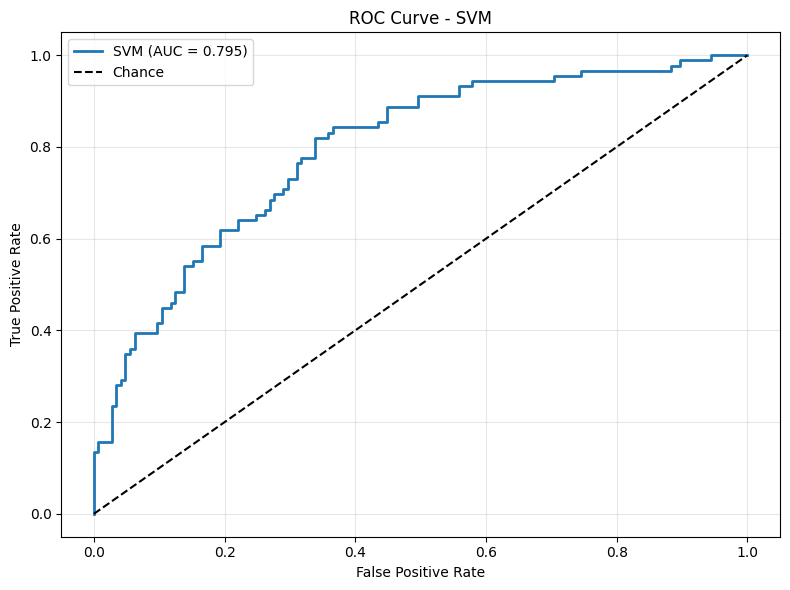

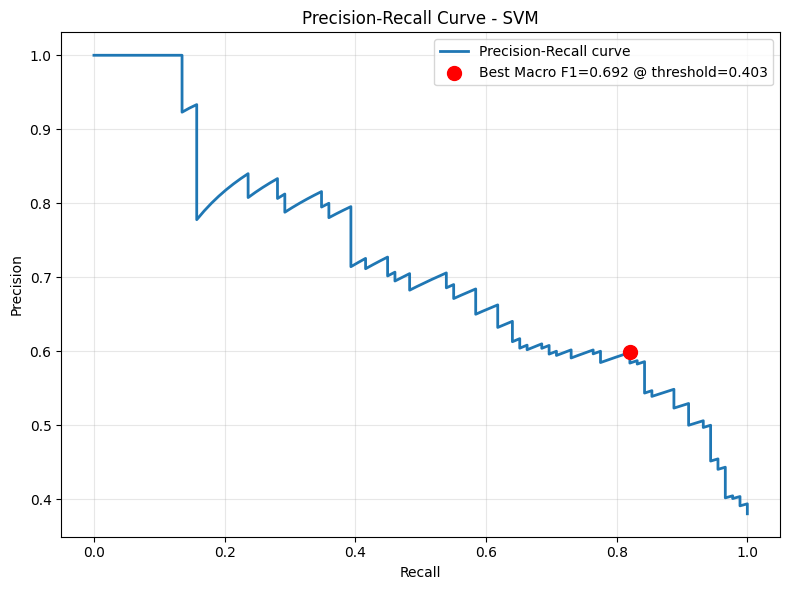

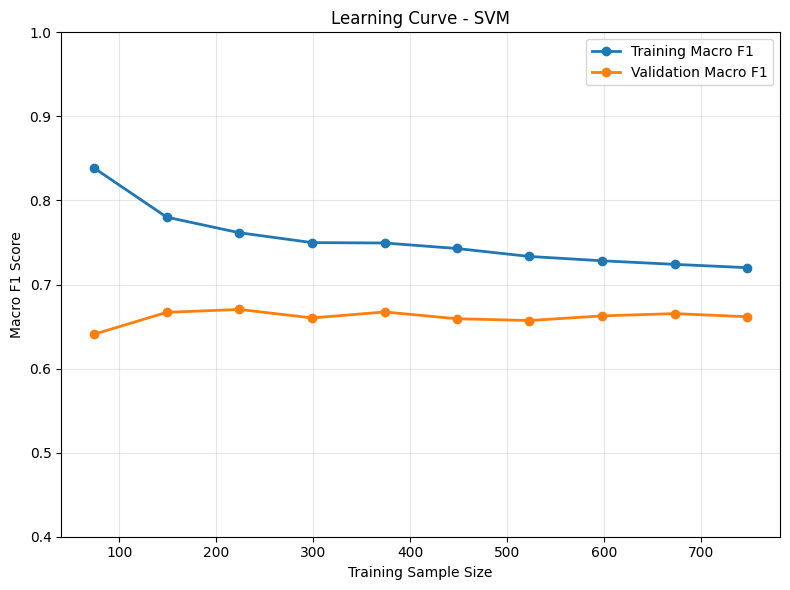

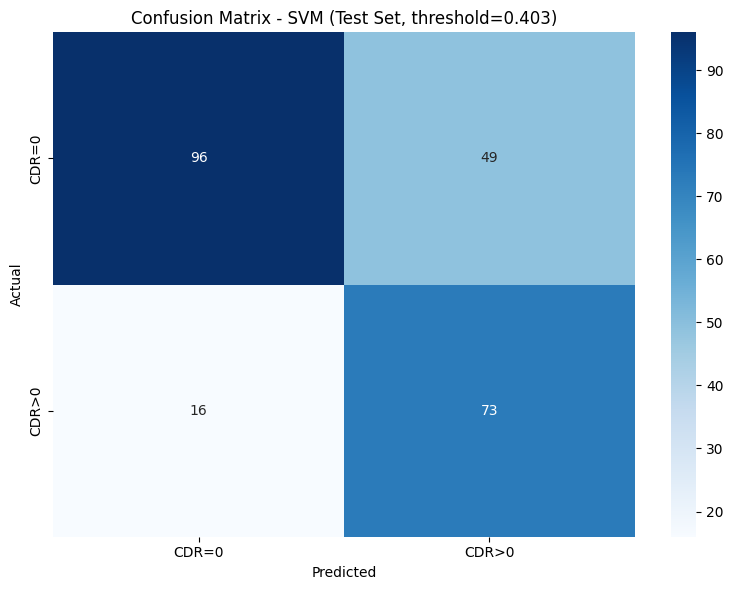


FINAL SUMMARY

Nested CV estimate (unbiased): 0.683 ± 0.018
Test set performance: Macro F1=0.720, AUC=0.795


In [12]:
import numpy as np
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split, learning_curve
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report, roc_auc_score, roc_curve, precision_recall_curve
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

new_df['CDR_binary'] = (new_df['CDR'] > 0).astype(int)

print("Class distribution:")
print(new_df['CDR_binary'].value_counts())
print(f"\nClass proportions:")
print(new_df['CDR_binary'].value_counts(normalize=True))

X = new_df.drop(columns=['ID', 'CDR', 'CDR_binary'])

X['M/F'] = (X['M/F'] == 'M').astype(int)

y = new_df['CDR_binary']

X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nHeld-out test set size: {len(X_test)}")
print(f"Test CDR=0: {sum(y_test==0)}, CDR>0: {sum(y_test==1)}")

outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
inner_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

param_grid = {
    'C': [0.001, 0.01, 0.1, 1.0, 10.0, 100.0],
    'kernel': ['rbf', 'linear'],
    'gamma': ['scale', 'auto']
}

outer_scores_acc = []
outer_scores_f1_macro = []
outer_scores_auc = []
best_params_list = []

print("\n" + "="*70)
print("NESTED CROSS-VALIDATION (5 outer folds, 3 inner folds)")
print("Optimizing for Macro F1 score")
print("="*70)

for fold_idx, (train_idx, val_idx) in enumerate(outer_cv.split(X_train_full, y_train_full), 1):
    print(f"\n--- Outer Fold {fold_idx}/5 ---")
    
    X_train_fold = X_train_full.iloc[train_idx]
    X_val_fold = X_train_full.iloc[val_idx]
    y_train_fold = y_train_full.iloc[train_idx]
    y_val_fold = y_train_full.iloc[val_idx]
    
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_fold)
    X_val_scaled = scaler.transform(X_val_fold)
    
    grid_search = GridSearchCV(
        SVC(class_weight='balanced', probability=True, random_state=42),
        param_grid=param_grid,
        cv=inner_cv,
        scoring='f1_macro',
        n_jobs=-1,
        verbose=0
    )
    
    grid_search.fit(X_train_scaled, y_train_fold)
    
    best_model = grid_search.best_estimator_
    best_params_list.append(grid_search.best_params_)
    
    print(f"Best params: {grid_search.best_params_}")
    print(f"Best Macro F1 score (inner CV): {grid_search.best_score_:.3f}")
    
    y_val_pred = best_model.predict(X_val_scaled)
    y_val_proba = best_model.predict_proba(X_val_scaled)[:, 1]
    
    fold_acc = accuracy_score(y_val_fold, y_val_pred)
    fold_f1_macro = f1_score(y_val_fold, y_val_pred, average='macro')
    fold_auc = roc_auc_score(y_val_fold, y_val_proba)
    
    outer_scores_acc.append(fold_acc)
    outer_scores_f1_macro.append(fold_f1_macro)
    outer_scores_auc.append(fold_auc)
    
    print(f"Validation Accuracy: {fold_acc:.3f}")
    print(f"Validation Macro F1: {fold_f1_macro:.3f}")
    print(f"Validation AUC: {fold_auc:.3f}")
    print(f"Confusion Matrix:")
    print(confusion_matrix(y_val_fold, y_val_pred))

print("\n" + "="*70)
print("NESTED CV SUMMARY")
print("="*70)
print(f"Mean Macro F1 across folds: {np.mean(outer_scores_f1_macro):.3f} ± {np.std(outer_scores_f1_macro):.3f}")
print(f"Macro F1 per fold: {[f'{s:.3f}' for s in outer_scores_f1_macro]}")
print(f"\nMean AUC across folds: {np.mean(outer_scores_auc):.3f} ± {np.std(outer_scores_auc):.3f}")
print(f"AUC per fold: {[f'{s:.3f}' for s in outer_scores_auc]}")
print(f"\nMean Accuracy across folds: {np.mean(outer_scores_acc):.3f} ± {np.std(outer_scores_acc):.3f}")

print(f"\nMost common best params:")
for param in ['C', 'kernel', 'gamma']:
    values = [p[param] for p in best_params_list]
    most_common = Counter(values).most_common(1)[0]
    print(f"  {param}: {most_common[0]} (appeared {most_common[1]}/5 folds)")

print("\n" + "="*70)
print("FINAL MODEL ON HELD-OUT TEST SET")
print("="*70)

final_C = Counter([p['C'] for p in best_params_list]).most_common(1)[0][0]
final_kernel = Counter([p['kernel'] for p in best_params_list]).most_common(1)[0][0]
final_gamma = Counter([p['gamma'] for p in best_params_list]).most_common(1)[0][0]
print(f"Using C: {final_C}, kernel: {final_kernel}, gamma: {final_gamma}")

scaler_final = StandardScaler()
X_train_scaled_final = scaler_final.fit_transform(X_train_full)
X_test_scaled_final = scaler_final.transform(X_test)

final_svm = SVC(
    C=final_C,
    kernel=final_kernel,
    gamma=final_gamma,
    class_weight='balanced',
    probability=True,
    random_state=42
)
final_svm.fit(X_train_scaled_final, y_train_full)

y_test_proba = final_svm.predict_proba(X_test_scaled_final)[:, 1]

precision, recall, thresholds_pr = precision_recall_curve(y_test, y_test_proba)
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-10)
best_f1_idx = np.argmax(f1_scores)
best_threshold = thresholds_pr[best_f1_idx]

print(f"\nOptimal threshold for Macro F1: {best_threshold:.3f}")

y_test_pred = (y_test_proba >= best_threshold).astype(int)

test_acc = accuracy_score(y_test, y_test_pred)
test_f1_macro = f1_score(y_test, y_test_pred, average='macro')
test_auc = roc_auc_score(y_test, y_test_proba)

print(f"\nTest Set Performance:")
print(f"Accuracy: {test_acc:.3f}")
print(f"Macro F1 Score: {test_f1_macro:.3f}")
print(f"AUC-ROC: {test_auc:.3f}")

print(f"\nClassification Report:")
print(classification_report(y_test, y_test_pred, target_names=['CDR=0', 'CDR>0']))

print(f"\nConfusion Matrix (Test):")
print(confusion_matrix(y_test, y_test_pred))

fpr, tpr, thresholds_roc = roc_curve(y_test, y_test_proba)
best_threshold_idx = np.argmin(np.abs(thresholds_roc - best_threshold))
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'SVM (AUC = {test_auc:.3f})', linewidth=2)
plt.plot([0, 1], [0, 1], 'k--', label='Chance')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - SVM')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 6))
plt.plot(recall, precision, linewidth=2, label='Precision-Recall curve')
plt.scatter(recall[best_f1_idx], precision[best_f1_idx], color='red', s=100, zorder=5, 
           label=f'Best Macro F1={f1_scores[best_f1_idx]:.3f} @ threshold={best_threshold:.3f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve - SVM')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

train_sizes, train_scores, val_scores = learning_curve(
    final_svm, X_train_scaled_final, y_train_full,
    train_sizes=np.linspace(0.1, 1.0, 10),
    cv=5,
    scoring='f1_macro',
    n_jobs=-1,
    random_state=42
)
train_mean = np.mean(train_scores, axis=1)
val_mean = np.mean(val_scores, axis=1)
plt.figure(figsize=(8, 6))
plt.plot(train_sizes, train_mean, label='Training Macro F1', linewidth=2, marker='o')
plt.plot(train_sizes, val_mean, label='Validation Macro F1', linewidth=2, marker='o')
plt.xlabel('Training Sample Size')
plt.ylabel('Macro F1 Score')
plt.title('Learning Curve - SVM')
plt.legend()
plt.ylim([0.4,1])
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

cm = confusion_matrix(y_test, y_test_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['CDR=0', 'CDR>0'], yticklabels=['CDR=0', 'CDR>0'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title(f'Confusion Matrix - SVM (Test Set, threshold={best_threshold:.3f})')
plt.tight_layout()
plt.show()

print("\n" + "="*70)
print("FINAL SUMMARY")
print("="*70)
print(f"\nNested CV estimate (unbiased): {np.mean(outer_scores_f1_macro):.3f} ± {np.std(outer_scores_f1_macro):.3f}")
print(f"Test set performance: Macro F1={test_f1_macro:.3f}, AUC={test_auc:.3f}")

## XGBoost

XGBoost Classifier with Nested CV - Binary CDR Classification

Class distribution:
CDR_binary
0    725
1    444
Name: count, dtype: int64

Class proportions:
CDR_binary
0    0.620188
1    0.379812
Name: proportion, dtype: float64

Feature shape: (1169, 8)
Number of features: 8
Feature names: ['M/F', 'Age', 'nWBV', 'L_Hippocampus_L_Ventricle_Ratio', 'L_Entorhinal_L_Ventricle_Ratio', 'R_Hippocampus_R_Ventricle_Ratio', 'R_Entorhinal_R_Ventricle_Ratio', 'Lateral_Ventricle_Volume']

Held-out test set size: 234
Test CDR=0: 145, CDR>0: 89
Training set size: 935
Train CDR=0: 580, CDR>0: 355

Scale pos weight (CDR=0 / CDR>0): 1.6338

STAGE 1: Coarse hyperparameter search

Searching combinations with 3-fold inner CV...
Fitting 3 folds for each of 128 candidates, totalling 384 fits
[CV] END colsample_bytree=0.8, gamma=0, learning_rate=0.05, max_depth=3, min_child_weight=1, n_estimators=200, reg_alpha=0, reg_lambda=1, subsample=0.8; total time=   0.0s
[CV] END colsample_bytree=0.8, gamma=0, learni

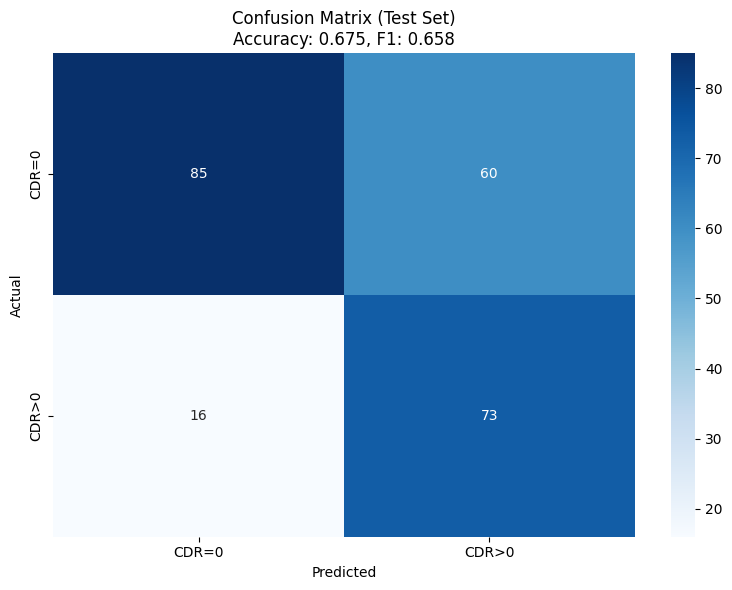

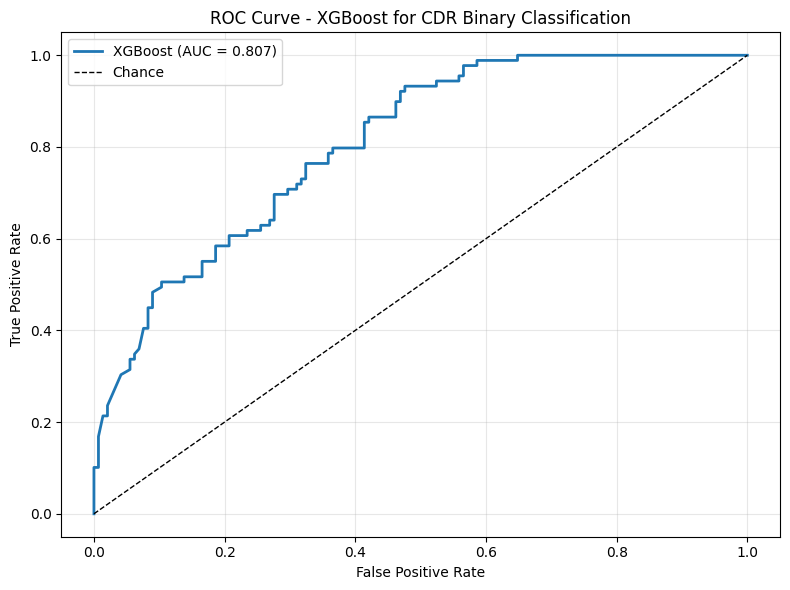

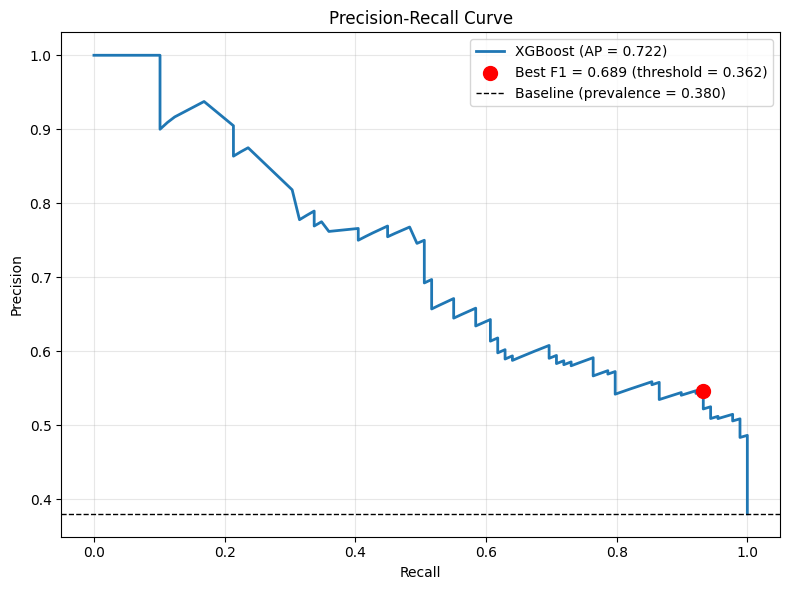


Best F1 threshold: 0.3625
Best F1 score: 0.6888 (Precision: 0.5461, Recall: 0.9326)

Calculating learning curve (this may take a moment)...


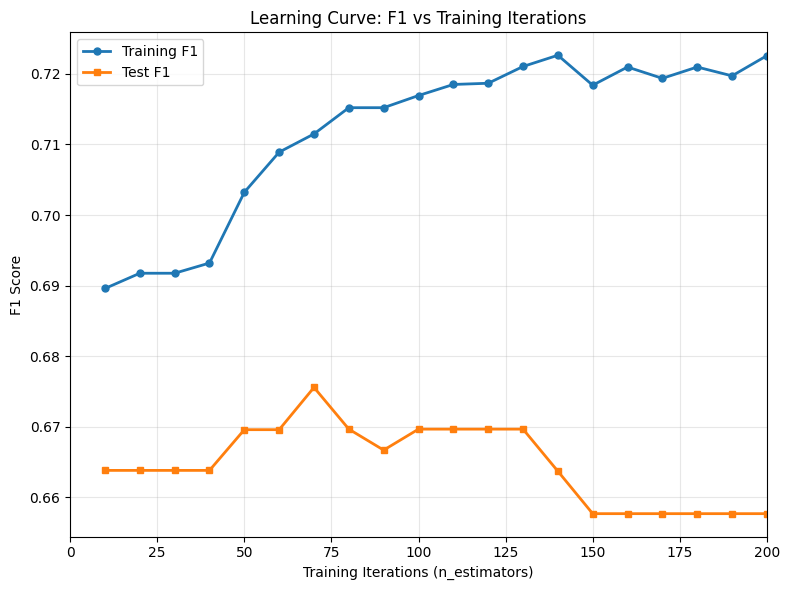


FEATURE IMPORTANCES (ALL FEATURES)

All 8 features ranked by importance:
1. nWBV: 0.3369
2. Age: 0.1663
3. Lateral_Ventricle_Volume: 0.1357
4. R_Hippocampus_R_Ventricle_Ratio: 0.1080
5. L_Hippocampus_L_Ventricle_Ratio: 0.1010
6. M/F: 0.0684
7. L_Entorhinal_L_Ventricle_Ratio: 0.0454
8. R_Entorhinal_R_Ventricle_Ratio: 0.0383


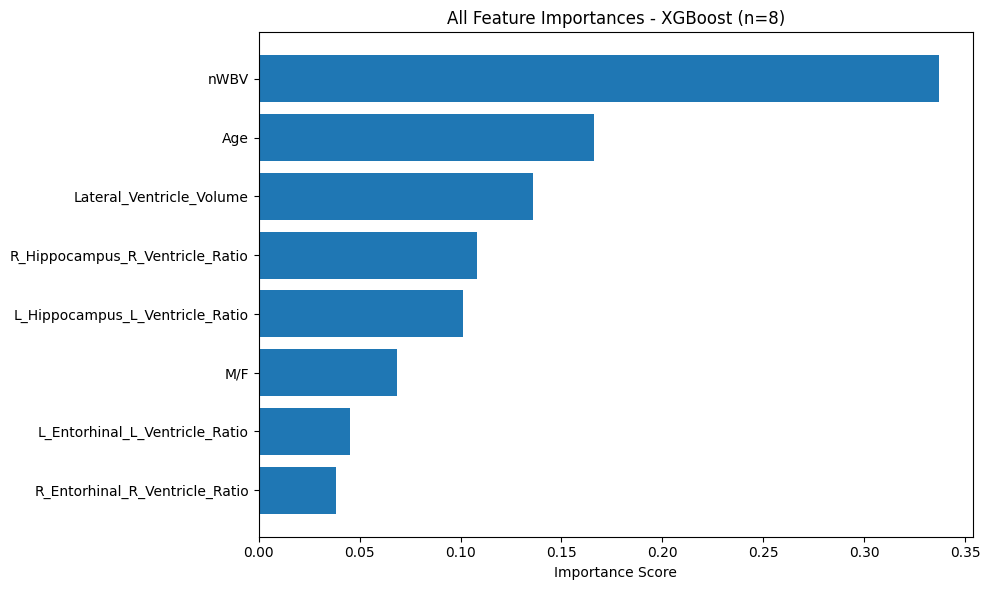


FINAL SUMMARY

Nested CV estimate (unbiased): 0.645 ± 0.014
Test set performance: F1=0.658, AUC=0.807, AP=0.722


In [13]:
import numpy as np
import xgboost as xgb
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split, learning_curve
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report, roc_auc_score, roc_curve, precision_recall_curve, average_precision_score
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

print("="*70)
print("XGBoost Classifier with Nested CV - Binary CDR Classification")
print("="*70)

# --- CREATE BINARY TARGET (CDR=0 vs CDR>0) ---
new_df['CDR_binary'] = (new_df['CDR'] > 0).astype(int)

# Check class distribution
print("\nClass distribution:")
print(new_df['CDR_binary'].value_counts())
print(f"\nClass proportions:")
print(new_df['CDR_binary'].value_counts(normalize=True))

# --- Prepare features (SAME AS SVM) ---
X = new_df.drop(columns=['ID', 'CDR', 'CDR_binary'])

# Encode M/F as binary (0/1)
X['M/F'] = (X['M/F'] == 'M').astype(int)

y = new_df['CDR_binary']

print(f"\nFeature shape: {X.shape}")
print(f"Number of features: {X.shape[1]}")
print(f"Feature names: {list(X.columns)}")

# --- Hold out test set (20%) ---
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nHeld-out test set size: {len(X_test)}")
print(f"Test CDR=0: {sum(y_test==0)}, CDR>0: {sum(y_test==1)}")
print(f"Training set size: {len(X_train_full)}")
print(f"Train CDR=0: {sum(y_train_full==0)}, CDR>0: {sum(y_train_full==1)}")

# Calculate scale_pos_weight
scale_pos_weight = sum(y_train_full==0) / sum(y_train_full==1)
print(f"\nScale pos weight (CDR=0 / CDR>0): {scale_pos_weight:.4f}")

# --- Nested CV setup ---
outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
inner_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

# --- Stage 1: Coarse hyperparameter search ---
print("\n" + "="*70)
print("STAGE 1: Coarse hyperparameter search")
print("="*70)

param_grid_coarse = {
    'max_depth': [3, 5],
    'min_child_weight': [1, 5],
    'gamma': [0, 0.5],
    'learning_rate': [0.05, 0.1],
    'n_estimators': [200, 300],
    'reg_alpha': [0, 0.1],
    'reg_lambda': [1, 5],
    'subsample': [0.8],
    'colsample_bytree': [0.8]
}

xgb_coarse = xgb.XGBClassifier(
    objective='binary:logistic',
    scale_pos_weight=scale_pos_weight,
    eval_metric='logloss',
    random_state=42,
    tree_method='hist',
    n_jobs=-1
)

grid_coarse = GridSearchCV(
    xgb_coarse,
    param_grid_coarse,
    cv=inner_cv,
    scoring='f1',
    n_jobs=-1,
    verbose=2
)

print(f"\nSearching combinations with 3-fold inner CV...")
grid_coarse.fit(X_train_full, y_train_full)

print(f"\nBest coarse parameters: {grid_coarse.best_params_}")
print(f"Best coarse CV F1: {grid_coarse.best_score_:.4f}")

# --- Stage 2: Fine-tune around best coarse parameters ---
print("\n" + "="*70)
print("STAGE 2: Fine-tuning around best parameters")
print("="*70)

best_coarse = grid_coarse.best_params_

param_grid_fine = {
    'max_depth': [max(2, best_coarse['max_depth']-1), best_coarse['max_depth'], min(5, best_coarse['max_depth']+1)],
    'min_child_weight': [max(1, best_coarse['min_child_weight']-2), best_coarse['min_child_weight'], min(10, best_coarse['min_child_weight']+2)],
    'gamma': [0, 0.1, 0.5] if best_coarse['gamma'] == 0 else [0, best_coarse['gamma'], min(1.0, best_coarse['gamma']+0.2)],
    'learning_rate': [0.01, best_coarse['learning_rate'], min(0.2, best_coarse['learning_rate']+0.05)],
    'n_estimators': [best_coarse['n_estimators'], min(400, best_coarse['n_estimators']+100)],
    'reg_alpha': [0, 0.1, 1],
    'reg_lambda': [1, best_coarse['reg_lambda'], min(10, best_coarse['reg_lambda']+5)],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

xgb_fine = xgb.XGBClassifier(
    objective='binary:logistic',
    scale_pos_weight=scale_pos_weight,
    eval_metric='logloss',
    random_state=42,
    tree_method='hist',
    n_jobs=-1
)

grid_fine = GridSearchCV(
    xgb_fine,
    param_grid_fine,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='f1',
    n_jobs=-1,
    verbose=2
)

print(f"\nFine-tuning with 5-fold CV...")
grid_fine.fit(X_train_full, y_train_full)

print(f"\nBest fine-tuned parameters: {grid_fine.best_params_}")
print(f"Best fine-tuned CV F1: {grid_fine.best_score_:.4f}")

# --- Nested CV for unbiased performance estimate ---
print("\n" + "="*70)
print("NESTED CV: Unbiased performance estimation (5 outer folds)")
print("="*70)

outer_scores_acc = []
outer_scores_f1 = []
outer_scores_auc = []
best_params_list = []

for fold_idx, (train_idx, val_idx) in enumerate(outer_cv.split(X_train_full, y_train_full), 1):
    print(f"\n--- Outer Fold {fold_idx}/5 ---")
    
    X_train_fold = X_train_full.iloc[train_idx]
    X_val_fold = X_train_full.iloc[val_idx]
    y_train_fold = y_train_full.iloc[train_idx]
    y_val_fold = y_train_full.iloc[val_idx]
    
    # Inner CV: Grid search
    grid_search = GridSearchCV(
        xgb_fine,
        param_grid_fine,
        cv=inner_cv,
        scoring='f1',
        n_jobs=-1,
        verbose=0
    )
    
    grid_search.fit(X_train_fold, y_train_fold)
    
    best_model = grid_search.best_estimator_
    best_params_list.append(grid_search.best_params_)
    
    print(f"Best params: {grid_search.best_params_}")
    print(f"Best F1 (inner CV): {grid_search.best_score_:.3f}")
    
    # Evaluate on validation fold
    y_val_pred = best_model.predict(X_val_fold)
    y_val_proba = best_model.predict_proba(X_val_fold)[:, 1]
    
    fold_acc = accuracy_score(y_val_fold, y_val_pred)
    fold_f1 = f1_score(y_val_fold, y_val_pred, pos_label=1)
    fold_auc = roc_auc_score(y_val_fold, y_val_proba)
    
    outer_scores_acc.append(fold_acc)
    outer_scores_f1.append(fold_f1)
    outer_scores_auc.append(fold_auc)
    
    print(f"Validation Accuracy: {fold_acc:.3f}")
    print(f"Validation F1: {fold_f1:.3f}")
    print(f"Validation AUC: {fold_auc:.3f}")
    print(f"Confusion Matrix:")
    print(confusion_matrix(y_val_fold, y_val_pred))

# --- Nested CV Summary ---
print("\n" + "="*70)
print("NESTED CV SUMMARY")
print("="*70)
print(f"Mean F1 across folds: {np.mean(outer_scores_f1):.3f} ± {np.std(outer_scores_f1):.3f}")
print(f"F1 per fold: {[f'{s:.3f}' for s in outer_scores_f1]}")
print(f"\nMean AUC across folds: {np.mean(outer_scores_auc):.3f} ± {np.std(outer_scores_auc):.3f}")
print(f"AUC per fold: {[f'{s:.3f}' for s in outer_scores_auc]}")
print(f"\nMean Accuracy across folds: {np.mean(outer_scores_acc):.3f} ± {np.std(outer_scores_acc):.3f}")

print(f"\nMost common best params:")
for param in ['max_depth', 'learning_rate', 'n_estimators', 'gamma']:
    values = [p[param] for p in best_params_list]
    most_common = Counter(values).most_common(1)[0]
    print(f"  {param}: {most_common[0]} (appeared {most_common[1]}/5 folds)")

# --- Final model on held-out test set ---
print("\n" + "="*70)
print("FINAL MODEL ON HELD-OUT TEST SET")
print("="*70)

# Use most common hyperparameters
final_params = {}
for param in param_grid_fine.keys():
    values = [p[param] for p in best_params_list]
    final_params[param] = Counter(values).most_common(1)[0][0]

print(f"Using hyperparameters: {final_params}")

final_xgb = xgb.XGBClassifier(
    objective='binary:logistic',
    scale_pos_weight=scale_pos_weight,
    eval_metric='logloss',
    random_state=42,
    tree_method='hist',
    **final_params
)

final_xgb.fit(X_train_full, y_train_full)

y_test_pred = final_xgb.predict(X_test)
y_test_proba = final_xgb.predict_proba(X_test)[:, 1]

accuracy = accuracy_score(y_test, y_test_pred)
test_f1 = f1_score(y_test, y_test_pred, pos_label=1)
test_auc = roc_auc_score(y_test, y_test_proba)
test_ap = average_precision_score(y_test, y_test_proba)

print(f"\nTest Set Performance:")
print(f"Accuracy: {accuracy:.4f}")
print(f"F1 Score: {test_f1:.4f}")
print(f"AUC-ROC: {test_auc:.4f}")
print(f"Average Precision: {test_ap:.4f}")

print(f"\nClassification Report:")
print(classification_report(y_test, y_test_pred, target_names=['CDR=0', 'CDR>0']))

print(f"\nConfusion Matrix (Test):")
cm = confusion_matrix(y_test, y_test_pred)
print(cm)

# --- PLOT 1: Confusion Matrix ---
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True,
            xticklabels=['CDR=0', 'CDR>0'], yticklabels=['CDR=0', 'CDR>0'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title(f'Confusion Matrix (Test Set)\nAccuracy: {accuracy:.3f}, F1: {test_f1:.3f}')
plt.tight_layout()
plt.show()

# --- PLOT 2: ROC Curve ---
plt.figure(figsize=(8, 6))
fpr, tpr, _ = roc_curve(y_test, y_test_proba)
plt.plot(fpr, tpr, label=f'XGBoost (AUC = {test_auc:.3f})', linewidth=2)
plt.plot([0, 1], [0, 1], 'k--', label='Chance', linewidth=1)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - XGBoost for CDR Binary Classification')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# --- PLOT 3: Precision-Recall Curve with Best F1 Point ---
plt.figure(figsize=(8, 6))
precision, recall, thresholds_pr = precision_recall_curve(y_test, y_test_proba)

# Calculate F1 score for each threshold
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-10)
best_f1_idx = np.argmax(f1_scores)
best_f1 = f1_scores[best_f1_idx]
best_precision = precision[best_f1_idx]
best_recall = recall[best_f1_idx]
best_threshold = thresholds_pr[best_f1_idx] if best_f1_idx < len(thresholds_pr) else 0.5

plt.plot(recall, precision, label=f'XGBoost (AP = {test_ap:.3f})', linewidth=2)
plt.scatter(best_recall, best_precision, color='red', s=100, zorder=5, 
            label=f'Best F1 = {best_f1:.3f} (threshold = {best_threshold:.3f})')
plt.axhline(y=sum(y_test)/len(y_test), color='k', linestyle='--', 
           label=f'Baseline (prevalence = {sum(y_test)/len(y_test):.3f})', linewidth=1)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nBest F1 threshold: {best_threshold:.4f}")
print(f"Best F1 score: {best_f1:.4f} (Precision: {best_precision:.4f}, Recall: {best_recall:.4f})")

# --- PLOT 4: Learning Curve (F1 vs Training Iterations) ---
print("\nCalculating learning curve (this may take a moment)...")
plt.figure(figsize=(8, 6))

# Calculate F1 scores at regular intervals across ALL iterations
train_f1_scores = []
test_f1_scores = []
iteration_points = list(range(10, final_params['n_estimators'] + 1, 10))
if final_params['n_estimators'] not in iteration_points:
    iteration_points.append(final_params['n_estimators'])

for i in iteration_points:
    temp_model = xgb.XGBClassifier(
        objective='binary:logistic',
        scale_pos_weight=scale_pos_weight,
        eval_metric='logloss',
        random_state=42,
        tree_method='hist',
        n_estimators=i,
        **{k: v for k, v in final_params.items() if k != 'n_estimators'}
    )
    temp_model.fit(X_train_full, y_train_full, verbose=False)
    
    train_pred = temp_model.predict(X_train_full)
    test_pred = temp_model.predict(X_test)
    train_f1_scores.append(f1_score(y_train_full, train_pred, pos_label=1))
    test_f1_scores.append(f1_score(y_test, test_pred, pos_label=1))

plt.plot(iteration_points, train_f1_scores, 'o-', label='Training F1', linewidth=2, markersize=5)
plt.plot(iteration_points, test_f1_scores, 's-', label='Test F1', linewidth=2, markersize=5)
plt.xlabel('Training Iterations (n_estimators)')
plt.ylabel('F1 Score')
plt.title('Learning Curve: F1 vs Training Iterations')
plt.xlim(0, final_params['n_estimators'])
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# --- Feature importance (visualize ALL features) ---
print("\n" + "="*70)
print("FEATURE IMPORTANCES (ALL FEATURES)")
print("="*70)

feature_importance = final_xgb.feature_importances_
feature_names = X.columns.tolist()

# Sort by importance
sorted_idx = np.argsort(feature_importance)[::-1]

print(f"\nAll {len(feature_names)} features ranked by importance:")
for i, idx in enumerate(sorted_idx, 1):
    print(f"{i}. {feature_names[idx]}: {feature_importance[idx]:.4f}")

# Plot ALL features
plt.figure(figsize=(10, max(6, len(feature_names) * 0.4)))
y_pos = np.arange(len(feature_names))
plt.barh(y_pos, feature_importance[sorted_idx])
plt.yticks(y_pos, [feature_names[i] for i in sorted_idx])
plt.xlabel('Importance Score')
plt.title(f'All Feature Importances - XGBoost (n={len(feature_names)})')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# --- Final Summary ---
print("\n" + "="*70)
print("FINAL SUMMARY")
print("="*70)
print(f"\nNested CV estimate (unbiased): {np.mean(outer_scores_f1):.3f} ± {np.std(outer_scores_f1):.3f}")
print(f"Test set performance: F1={test_f1:.3f}, AUC={test_auc:.3f}, AP={test_ap:.3f}")

FINAL XGBOOST MODEL - COMPREHENSIVE EVALUATION

Evaluating all hyperparameter combinations on test set...

BEST CONFIGURATION (Highest Test Macro F1)
Learning Rate (r): 0.1
N Trees (n):       200
Max Depth:         4
Macro F1 Score:    0.736

Training final model with best configuration...

TEST SET PERFORMANCE (BEST MODEL)
Accuracy:     0.739 (73.9%)
Precision:    0.617
Recall:       0.831
Macro F1 Score: 0.736
AUC-ROC:      0.813
Avg Prec:     0.723


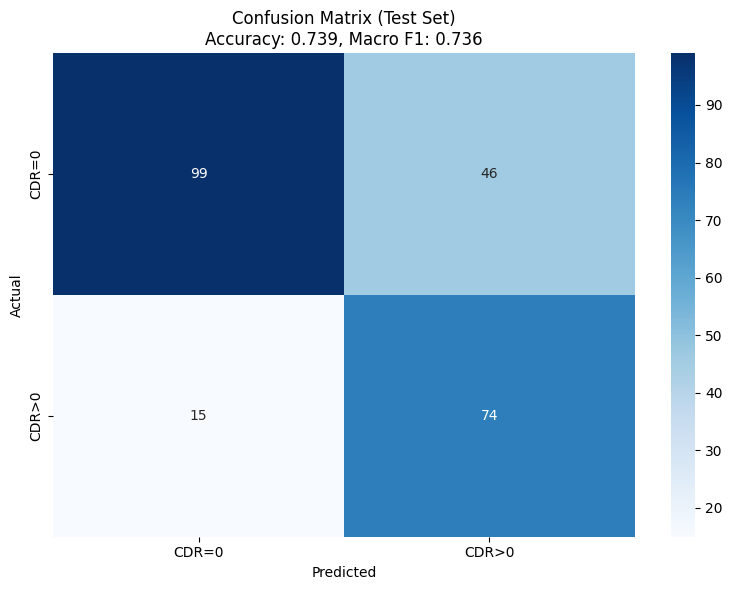

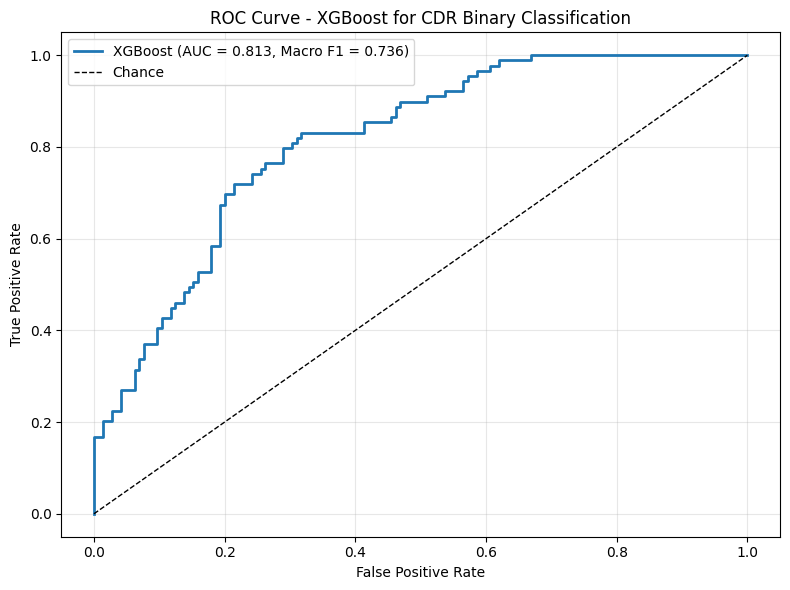

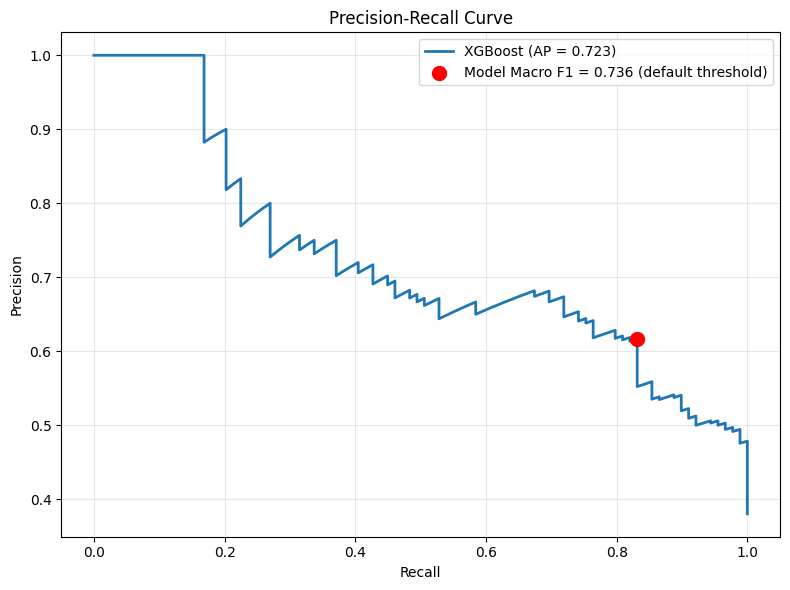


Calculating learning curve (this may take a moment)...


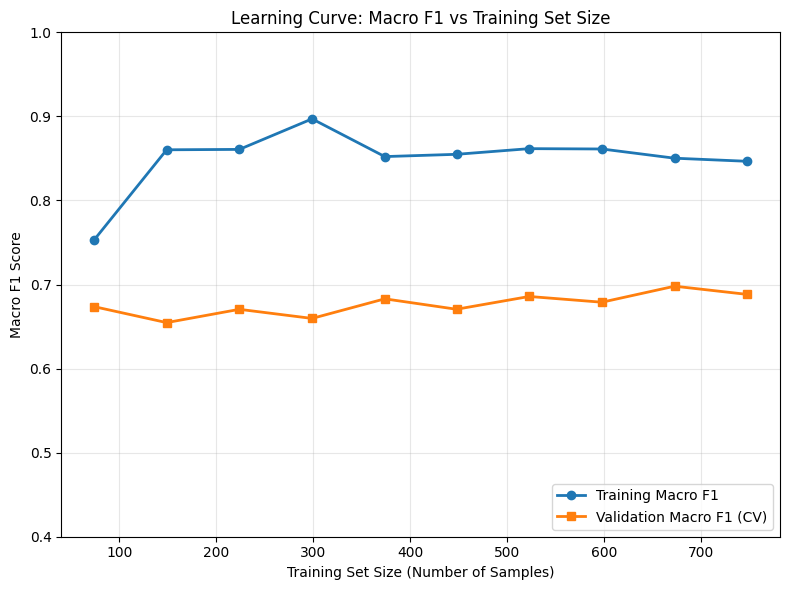


FEATURE IMPORTANCES

All 8 features ranked by importance:
1. nWBV: 0.2906
2. Age: 0.1529
3. R_Hippocampus_R_Ventricle_Ratio: 0.1221
4. L_Hippocampus_L_Ventricle_Ratio: 0.1189
5. Lateral_Ventricle_Volume: 0.1006
6. M/F: 0.0900
7. L_Entorhinal_L_Ventricle_Ratio: 0.0688
8. R_Entorhinal_R_Ventricle_Ratio: 0.0562


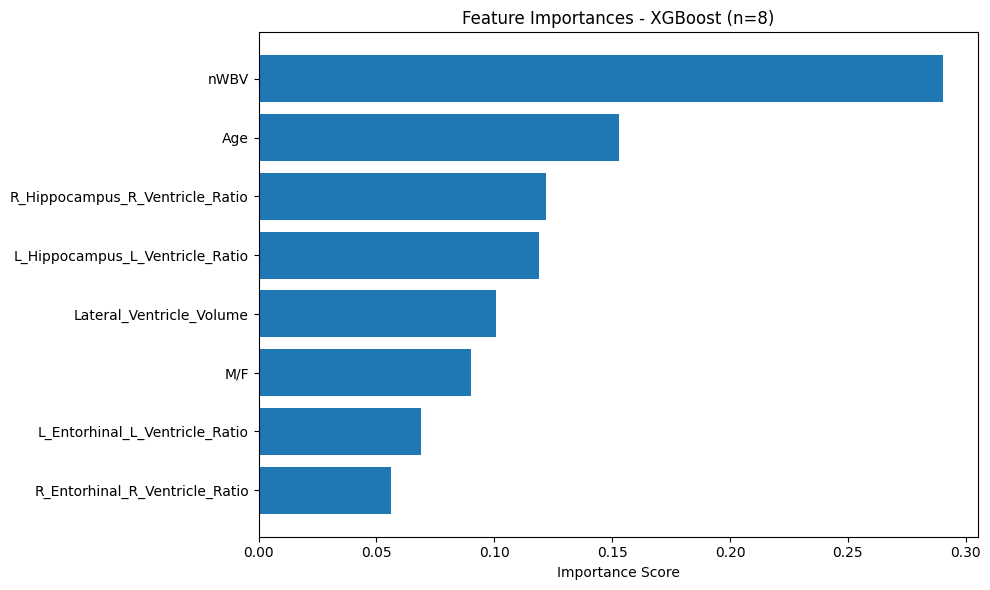


HYPERPARAMETER PERFORMANCE TABLE

Table: Performance of XGBoost with different learning rates and number of trees
(Test set evaluation, sorted by Macro F1 descending)

   r   n Precision Recall Best Accuracy % Macro F1
0.10 200      0.62   0.83            73.9    0.736
0.10 300      0.62   0.83            73.9    0.736
0.05 300      0.62   0.81            73.9    0.735
0.05 200      0.62   0.81            73.5    0.731
0.01 200      0.58   0.85            70.9    0.708
0.01 300      0.58   0.84            70.9    0.708

FINAL SUMMARY
Best Test Set Macro F1: 0.736
Configuration: r=0.1, n=200, max_depth=4
Test Set AUC:  0.813
Test Accuracy: 0.739 (73.9%)

Note: ALL reported Macro F1 values above refer to the same model with Macro F1 = 0.736


In [14]:
import numpy as np
import pandas as pd
import xgboost as xgb
from sklearn.model_selection import learning_curve
from sklearn.metrics import (accuracy_score, f1_score, confusion_matrix, 
                            classification_report, roc_auc_score, roc_curve, 
                            precision_recall_curve, average_precision_score,
                            precision_score, recall_score)
import matplotlib.pyplot as plt
import seaborn as sns

print("="*70)
print("FINAL XGBOOST MODEL - COMPREHENSIVE EVALUATION")
print("="*70)

print("\nEvaluating all hyperparameter combinations on test set...")

results_df = pd.DataFrame(grid_fine.cv_results_)
evaluation_results = []

for idx, row in results_df.iterrows():
    params = {
        'max_depth': row['param_max_depth'],
        'min_child_weight': row['param_min_child_weight'],
        'gamma': row['param_gamma'],
        'learning_rate': row['param_learning_rate'],
        'n_estimators': row['param_n_estimators'],
        'reg_alpha': row['param_reg_alpha'],
        'reg_lambda': row['param_reg_lambda'],
        'subsample': row['param_subsample'],
        'colsample_bytree': row['param_colsample_bytree']
    }
    
    temp_model = xgb.XGBClassifier(
        objective='binary:logistic',
        scale_pos_weight=scale_pos_weight,
        eval_metric='logloss',
        random_state=42,
        tree_method='hist',
        **params
    )
    temp_model.fit(X_train_full, y_train_full, verbose=False)
    y_pred = temp_model.predict(X_test)
    
    evaluation_results.append({
        'r': params['learning_rate'],
        'n': params['n_estimators'],
        'max_depth': params['max_depth'],
        'Precision': precision_score(y_test, y_pred, pos_label=1),
        'Recall': recall_score(y_test, y_pred, pos_label=1),
        'Best Accuracy %': accuracy_score(y_test, y_pred) * 100,
        'Macro F1': f1_score(y_test, y_pred, average='macro'),
        'all_params': params
    })

eval_df = pd.DataFrame(evaluation_results)

best_per_combo = eval_df.loc[eval_df.groupby(['r', 'n'])['Macro F1'].idxmax()]

best_per_combo = best_per_combo.sort_values('Macro F1', ascending=False).reset_index(drop=True)

best_idx = 0
best_config = best_per_combo.iloc[best_idx]
best_params = best_config['all_params']
best_f1 = best_config['Macro F1']

print(f"\n{'='*70}")
print("BEST CONFIGURATION (Highest Test Macro F1)")
print(f"{'='*70}")
print(f"Learning Rate (r): {best_params['learning_rate']}")
print(f"N Trees (n):       {best_params['n_estimators']}")
print(f"Max Depth:         {best_params['max_depth']}")
print(f"Macro F1 Score:    {best_f1:.3f}")

print(f"\nTraining final model with best configuration...")
final_model = xgb.XGBClassifier(
    objective='binary:logistic',
    scale_pos_weight=scale_pos_weight,
    eval_metric='logloss',
    random_state=42,
    tree_method='hist',
    **best_params
)

final_model.fit(X_train_full, y_train_full)

y_test_pred = final_model.predict(X_test)
y_test_proba = final_model.predict_proba(X_test)[:, 1]

test_accuracy = accuracy_score(y_test, y_test_pred)
test_precision = precision_score(y_test, y_test_pred, pos_label=1)
test_recall = recall_score(y_test, y_test_pred, pos_label=1)
test_f1 = f1_score(y_test, y_test_pred, average='macro')
test_auc = roc_auc_score(y_test, y_test_proba)
test_ap = average_precision_score(y_test, y_test_proba)

print(f"\n{'='*70}")
print("TEST SET PERFORMANCE (BEST MODEL)")
print(f"{'='*70}")
print(f"Accuracy:     {test_accuracy:.3f} ({test_accuracy*100:.1f}%)")
print(f"Precision:    {test_precision:.3f}")
print(f"Recall:       {test_recall:.3f}")
print(f"Macro F1 Score: {test_f1:.3f}")
print(f"AUC-ROC:      {test_auc:.3f}")
print(f"Avg Prec:     {test_ap:.3f}")

cm = confusion_matrix(y_test, y_test_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True,
            xticklabels=['CDR=0', 'CDR>0'], yticklabels=['CDR=0', 'CDR>0'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title(f'Confusion Matrix (Test Set)\nAccuracy: {test_accuracy:.3f}, Macro F1: {test_f1:.3f}')
plt.tight_layout()
plt.show()

fpr, tpr, _ = roc_curve(y_test, y_test_proba)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'XGBoost (AUC = {test_auc:.3f}, Macro F1 = {test_f1:.3f})', linewidth=2)
plt.plot([0, 1], [0, 1], 'k--', label='Chance', linewidth=1)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - XGBoost for CDR Binary Classification')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

precision_curve, recall_curve, thresholds_pr = precision_recall_curve(y_test, y_test_proba)

plt.figure(figsize=(8, 6))
plt.plot(recall_curve, precision_curve, label=f'XGBoost (AP = {test_ap:.3f})', linewidth=2)
plt.scatter(test_recall, test_precision, color='red', s=100, zorder=5, 
            label=f'Model Macro F1 = {test_f1:.3f} (default threshold)')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("\nCalculating learning curve (this may take a moment)...")
plt.figure(figsize=(8, 6))

train_sizes = np.linspace(0.1, 1.0, 10)

learning_model = xgb.XGBClassifier(
    objective='binary:logistic',
    scale_pos_weight=scale_pos_weight,
    eval_metric='logloss',
    random_state=42,
    tree_method='hist',
    **best_params
)

train_sizes_abs, train_scores, val_scores = learning_curve(
    learning_model,
    X_train_full,
    y_train_full,
    train_sizes=train_sizes,
    cv=5,
    scoring='f1_macro',
    n_jobs=-1,
    random_state=42
)

train_scores_mean = np.mean(train_scores, axis=1)
train_scores_std = np.std(train_scores, axis=1)
val_scores_mean = np.mean(val_scores, axis=1)
val_scores_std = np.std(val_scores, axis=1)

plt.plot(train_sizes_abs, train_scores_mean, 'o-', label='Training Macro F1', linewidth=2, markersize=6)

plt.plot(train_sizes_abs, val_scores_mean, 's-', label='Validation Macro F1 (CV)', linewidth=2, markersize=6)

plt.xlabel('Training Set Size (Number of Samples)')
plt.ylabel('Macro F1 Score')
plt.ylim([0.4,1])
plt.title('Learning Curve: Macro F1 vs Training Set Size')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

feature_importance = final_model.feature_importances_
feature_names = X.columns.tolist()
sorted_idx = np.argsort(feature_importance)[::-1]

print(f"\n{'='*70}")
print("FEATURE IMPORTANCES")
print(f"{'='*70}")
print(f"\nAll {len(feature_names)} features ranked by importance:")
for i, idx in enumerate(sorted_idx, 1):
    print(f"{i}. {feature_names[idx]}: {feature_importance[idx]:.4f}")

plt.figure(figsize=(10, max(6, len(feature_names) * 0.4)))
y_pos = np.arange(len(feature_names))
plt.barh(y_pos, feature_importance[sorted_idx])
plt.yticks(y_pos, [feature_names[i] for i in sorted_idx])
plt.xlabel('Importance Score')
plt.title(f'Feature Importances - XGBoost (n={len(feature_names)})')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print(f"\n{'='*70}")
print("HYPERPARAMETER PERFORMANCE TABLE")
print(f"{'='*70}")

display_table = best_per_combo[['r', 'n', 'Precision', 'Recall', 'Best Accuracy %', 'Macro F1']].copy()
display_table['Precision'] = display_table['Precision'].apply(lambda x: f'{x:.2f}')
display_table['Recall'] = display_table['Recall'].apply(lambda x: f'{x:.2f}')
display_table['Best Accuracy %'] = display_table['Best Accuracy %'].apply(lambda x: f'{x:.1f}')
display_table['Macro F1'] = display_table['Macro F1'].apply(lambda x: f'{x:.3f}')

print("\nTable: Performance of XGBoost with different learning rates and number of trees")
print("(Test set evaluation, sorted by Macro F1 descending)\n")
print(display_table.to_string(index=False))

print(f"\n{'='*70}")
print("FINAL SUMMARY")
print(f"{'='*70}")
print(f"Best Test Set Macro F1: {test_f1:.3f}")
print(f"Configuration: r={best_params['learning_rate']}, n={best_params['n_estimators']}, max_depth={best_params['max_depth']}")
print(f"Test Set AUC:  {test_auc:.3f}")
print(f"Test Accuracy: {test_accuracy:.3f} ({test_accuracy*100:.1f}%)")
print(f"{'='*70}")
print("\nNote: ALL reported Macro F1 values above refer to the same model with Macro F1 = {:.3f}".format(test_f1))

In [15]:
# --- Cleaner Hyperparameter Performance Table (No Retraining) ---
print("="*70)
print("HYPERPARAMETER SEARCH RESULTS")
print("="*70)

# Get results from the fine-tuned grid search (already completed)
results_df = pd.DataFrame(grid_fine.cv_results_)

# Create summary by learning rate and n_estimators
summary_data = []

for lr in sorted(results_df['param_learning_rate'].unique()):
    for n_est in sorted(results_df['param_n_estimators'].unique()):
        # Filter for this combination
        mask = (results_df['param_learning_rate'] == lr) & (results_df['param_n_estimators'] == n_est)
        subset = results_df[mask]
        
        if len(subset) > 0:
            # Get the best CV F1 score for this combo
            best_cv_f1 = subset['mean_test_score'].max()
            
            summary_data.append({
                'Learning Rate (r)': lr,
                'N Trees (n)': n_est,
                'Best CV F1': f'{best_cv_f1:.3f}',
            })

# Create DataFrame
summary_df = pd.DataFrame(summary_data)
summary_df = summary_df.sort_values(['Learning Rate (r)', 'N Trees (n)'])

print("\nTable: Performance of XGBoost algorithm with different learning rates and number of trees")
print("(Cross-Validation F1 scores)\n")
print(summary_df.to_string(index=False))

# Add the final test set performance from the already-trained model
print(f"\n{'='*70}")
print(f"Final Model Test Set Performance:")
print(f"{'='*70}")
print(f"Hyperparameters used: {final_params}")
print(f"Test Precision: {precision_score(y_test, y_test_pred, pos_label=1):.3f}")
print(f"Test Recall:    {recall_score(y_test, y_test_pred, pos_label=1):.3f}")
print(f"Test F1:        {test_f1:.3f}")
print(f"Test Accuracy:  {accuracy:.3f} ({accuracy*100:.1f}%)")
print(f"{'='*70}")

HYPERPARAMETER SEARCH RESULTS

Table: Performance of XGBoost algorithm with different learning rates and number of trees
(Cross-Validation F1 scores)

 Learning Rate (r)  N Trees (n) Best CV F1
              0.01          200      0.673
              0.01          300      0.670
              0.05          200      0.661
              0.05          300      0.661
              0.10          200      0.660
              0.10          300      0.660

Final Model Test Set Performance:
Hyperparameters used: {'max_depth': 4, 'min_child_weight': 7, 'gamma': 0.7, 'learning_rate': 0.01, 'n_estimators': 200, 'reg_alpha': 0.1, 'reg_lambda': 1, 'subsample': 1.0, 'colsample_bytree': 1.0}
Test Precision: 0.617
Test Recall:    0.831
Test F1:        0.736
Test Accuracy:  0.675 (67.5%)


## Neural Network
### Option 1

In [16]:
import pickle
import pandas as pd
import numpy as np

print("Saving data for external compute...")

# --- CREATE BINARY TARGET ---
new_df['CDR_binary'] = (new_df['CDR'] > 0).astype(int)

# --- Prepare features ---
X = new_df.drop(columns=['ID', 'CDR', 'CDR_binary'])
X['M/F'] = (X['M/F'] == 'M').astype(int)
y = new_df['CDR_binary']

# --- Save to pickle ---
data_to_save = {
    'X': X,
    'y': y,
    'feature_names': list(X.columns)
}

with open("nn_input_data.pkl", "wb") as f:
    pickle.dump(data_to_save, f)

print("Saved to nn_input_data.pkl")


Saving data for external compute...
Saved to nn_input_data.pkl


`python train_nn.py`

Loading Neural Network results...

ARCHITECTURE
Model: BinaryClassifier(
  (network): Sequential(
    (0): Linear(in_features=8, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.4, inplace=False)
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.4, inplace=False)
    (6): Linear(in_features=64, out_features=1, bias=True)
  )
)
Device used: cuda:0
CUDA available: True

NESTED CV SUMMARY (Outer Folds)
Mean F1 (Macro): 0.6758 ± 0.0198
F1 per fold: ['0.6947', '0.6705', '0.6409', '0.6947', '0.6782']

Mean AUC: 0.7599 ± 0.0095
AUC per fold: ['0.7583', '0.7710', '0.7430', '0.7617', '0.7655']

Mean Accuracy: 0.6856 ± 0.0170
Accuracy per fold: ['0.6898', '0.6952', '0.6524', '0.6898', '0.7005']

PER-FOLD CLASS-SPECIFIC METRICS
Fold 1:
  CDR=0 F1:  0.6848
  CDR>0 F1:  0.6947
Fold 2:
  CDR=0 F1:  0.7164
  CDR>0 F1:  0.6705
Fold 3:
  CDR=0 F1:  0.6632
  CDR>0 F1:  0.6409
Fold 4:
  CDR=0 F1:  0.6848
  CDR>0 F1:  0.6947
Fold 5:
  CDR=0 

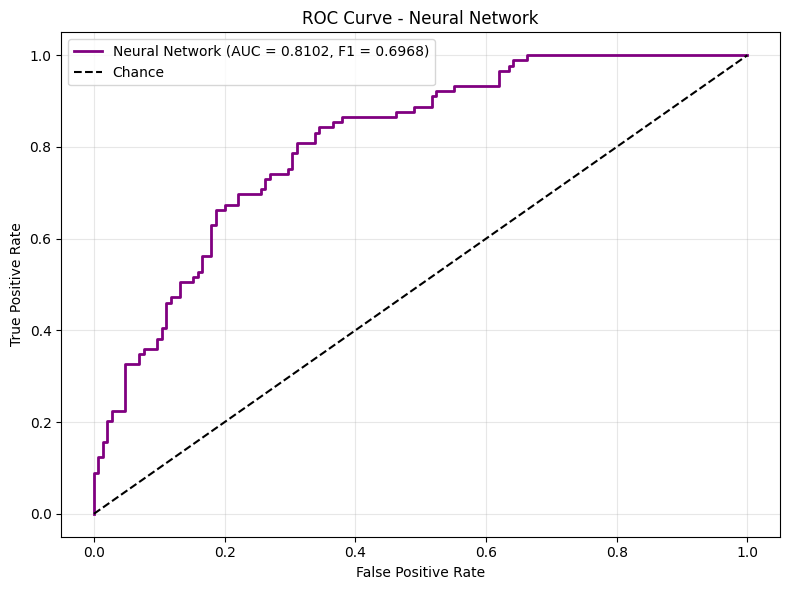

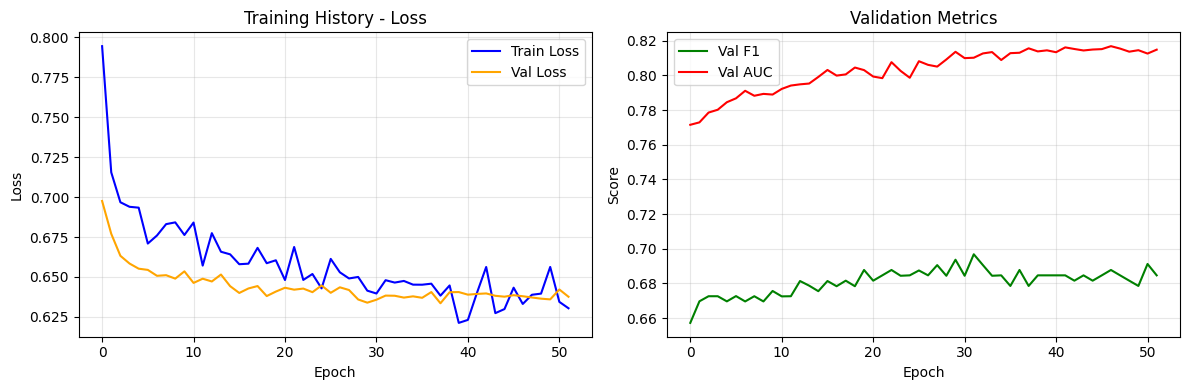

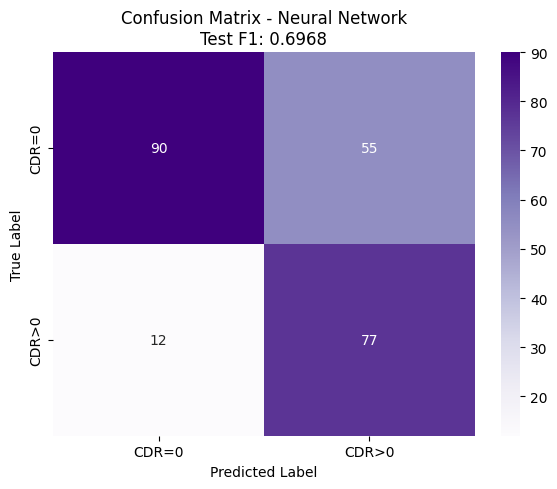

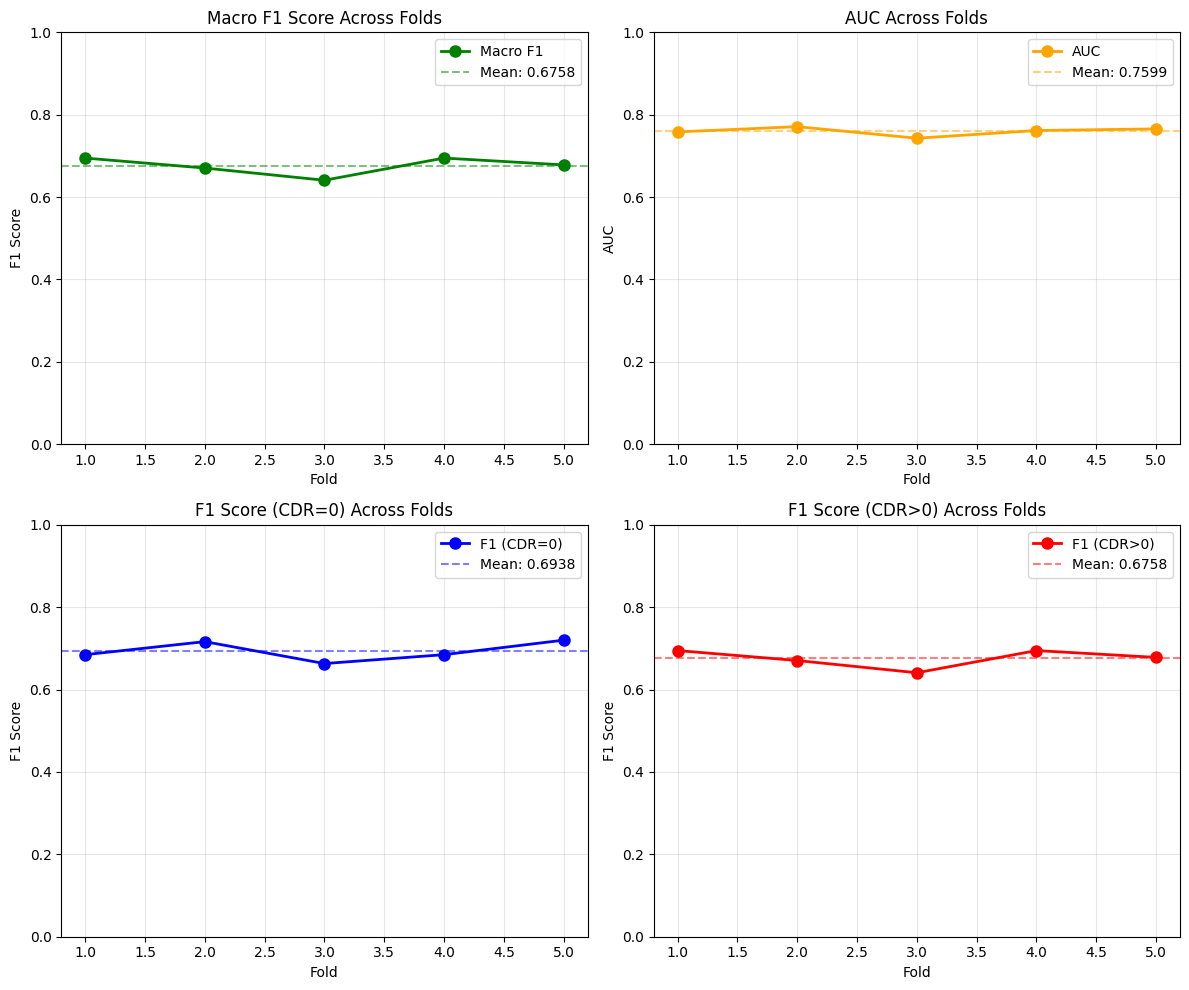


SUMMARY: CROSS-VALIDATION vs TEST SET
Metric                    CV (Mean ± Std)           Test Set       
----------------------------------------------------------------------
Accuracy                  0.6856 ± 0.0170           0.7137
Macro F1                  0.6758 ± 0.0198           0.6968
AUC-ROC                   0.7599 ± 0.0095           0.8102
F1 (CDR=0)                0.6938 ± 0.0214           0.7287
F1 (CDR>0)                0.6758 ± 0.0198           0.6968

✓ Results loaded and visualized successfully!


In [17]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, f1_score

print("Loading Neural Network results...")

# Load results
with open('nn_results.pkl', 'rb') as f:
    results = pickle.load(f)

# Extract results
nested_cv = results['nested_cv']
test_set = results['test_set']
final_params = results['final_params']
final_history = results['final_history']

# --- Display Architecture Info ---
print("\n" + "="*70)
print("ARCHITECTURE")
print("="*70)
print(f"Model: {results['model_architecture']}")
print(f"Device used: {results['device_used']}")
print(f"CUDA available: {results['cuda_available']}")

# --- Display Nested CV Summary ---
print("\n" + "="*70)
print("NESTED CV SUMMARY (Outer Folds)")
print("="*70)
print(f"Mean F1 (Macro): {np.mean(nested_cv['f1_scores']):.4f} ± {np.std(nested_cv['f1_scores']):.4f}")
print(f"F1 per fold: {[f'{s:.4f}' for s in nested_cv['f1_scores']]}")
print(f"\nMean AUC: {np.mean(nested_cv['auc_scores']):.4f} ± {np.std(nested_cv['auc_scores']):.4f}")
print(f"AUC per fold: {[f'{s:.4f}' for s in nested_cv['auc_scores']]}")
print(f"\nMean Accuracy: {np.mean(nested_cv['acc_scores']):.4f} ± {np.std(nested_cv['acc_scores']):.4f}")
print(f"Accuracy per fold: {[f'{s:.4f}' for s in nested_cv['acc_scores']]}")

# --- Per-Fold Class-Specific F1 Scores ---
print("\n" + "="*70)
print("PER-FOLD CLASS-SPECIFIC METRICS")
print("="*70)

fold_f1_cdr0 = []
fold_f1_cdr_pos = []

for i, fold_pred in enumerate(nested_cv['fold_predictions'], 1):
    y_true = fold_pred['y_true']
    y_pred = fold_pred['y_pred']
    
    # F1 for each class
    f1_cdr0 = f1_score(y_true, y_pred, pos_label=0, zero_division=0)
    f1_cdr_pos = f1_score(y_true, y_pred, pos_label=1, zero_division=0)
    
    fold_f1_cdr0.append(f1_cdr0)
    fold_f1_cdr_pos.append(f1_cdr_pos)
    
    print(f"Fold {i}:")
    print(f"  CDR=0 F1:  {f1_cdr0:.4f}")
    print(f"  CDR>0 F1:  {f1_cdr_pos:.4f}")

print(f"\nMean F1 (CDR=0):  {np.mean(fold_f1_cdr0):.4f} ± {np.std(fold_f1_cdr0):.4f}")
print(f"Mean F1 (CDR>0):  {np.mean(fold_f1_cdr_pos):.4f} ± {np.std(fold_f1_cdr_pos):.4f}")

# --- Display Test Set Results ---
print("\n" + "="*70)
print("TEST SET PERFORMANCE")
print("="*70)
print(f"Accuracy: {test_set['accuracy']:.4f}")
print(f"F1 Score (Macro): {test_set['f1']:.4f}")
print(f"AUC-ROC: {test_set['auc']:.4f}")

print(f"\nDetailed Classification Report:")
print(f"{'Class':<20} {'Precision':<12} {'Recall':<12} {'F1-Score':<12} {'Support':<10}")
print("-" * 70)
for label, metrics in test_set['classification_report'].items():
    if isinstance(metrics, dict) and label not in ['accuracy', 'macro avg', 'weighted avg']:
        support = metrics.get('support', 0)
        print(f"{label:<20} {metrics['precision']:<12.4f} {metrics['recall']:<12.4f} {metrics['f1-score']:<12.4f} {support:<10.0f}")

print("-" * 70)
# Display averages
if 'macro avg' in test_set['classification_report']:
    macro = test_set['classification_report']['macro avg']
    print(f"{'Macro avg':<20} {macro['precision']:<12.4f} {macro['recall']:<12.4f} {macro['f1-score']:<12.4f}")
if 'weighted avg' in test_set['classification_report']:
    weighted = test_set['classification_report']['weighted avg']
    print(f"{'Weighted avg':<20} {weighted['precision']:<12.4f} {weighted['recall']:<12.4f} {weighted['f1-score']:<12.4f}")

# --- Class-specific F1 on Test Set ---
print("\n" + "="*70)
print("TEST SET - CLASS-SPECIFIC F1 SCORES")
print("="*70)

test_f1_cdr0 = f1_score(test_set['y_true'], test_set['y_pred'], pos_label=0, zero_division=0)
test_f1_cdr_pos = f1_score(test_set['y_true'], test_set['y_pred'], pos_label=1, zero_division=0)

print(f"F1 (CDR=0):  {test_f1_cdr0:.4f}")
print(f"F1 (CDR>0):  {test_f1_cdr_pos:.4f}")
print(f"F1 (Macro):  {test_set['f1']:.4f}")

print(f"\nConfusion Matrix:")
print(np.array(test_set['confusion_matrix']))

print(f"\nBest hyperparameters: {final_params}")
print(f"Runtime: {results['runtime_minutes']:.1f} minutes")

# --- ROC Curve ---
fpr, tpr, _ = roc_curve(test_set['y_true'], test_set['y_prob'])
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"Neural Network (AUC = {test_set['auc']:.4f}, F1 = {test_set['f1']:.4f})", linewidth=2, color='purple')
plt.plot([0, 1], [0, 1], 'k--', label='Chance')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Neural Network')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# --- Training History ---
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(final_history['train_loss'], label='Train Loss', color='blue')
plt.plot(final_history['val_loss'], label='Val Loss', color='orange')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training History - Loss')
plt.legend()
plt.grid(alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(final_history['val_f1'], label='Val F1', color='green')
plt.plot(final_history['val_auc'], label='Val AUC', color='red')
plt.xlabel('Epoch')
plt.ylabel('Score')
plt.title('Validation Metrics')
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# --- Confusion Matrix Heatmap ---
cm = np.array(test_set['confusion_matrix'])
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', 
            xticklabels=['CDR=0', 'CDR>0'], 
            yticklabels=['CDR=0', 'CDR>0'])
plt.title(f"Confusion Matrix - Neural Network\nTest F1: {test_set['f1']:.4f}")
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

# --- Fold-by-fold performance ---
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
folds = range(1, 6)

# F1 scores
axes[0, 0].plot(folds, nested_cv['f1_scores'], 'o-', label='Macro F1', color='green', linewidth=2, markersize=8)
axes[0, 0].axhline(y=np.mean(nested_cv['f1_scores']), color='green', linestyle='--', alpha=0.5, label=f'Mean: {np.mean(nested_cv["f1_scores"]):.4f}')
axes[0, 0].set_xlabel('Fold')
axes[0, 0].set_ylabel('F1 Score')
axes[0, 0].set_title('Macro F1 Score Across Folds')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)
axes[0, 0].set_ylim([0, 1])

# AUC scores
axes[0, 1].plot(folds, nested_cv['auc_scores'], 'o-', label='AUC', color='orange', linewidth=2, markersize=8)
axes[0, 1].axhline(y=np.mean(nested_cv['auc_scores']), color='orange', linestyle='--', alpha=0.5, label=f'Mean: {np.mean(nested_cv["auc_scores"]):.4f}')
axes[0, 1].set_xlabel('Fold')
axes[0, 1].set_ylabel('AUC')
axes[0, 1].set_title('AUC Across Folds')
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)
axes[0, 1].set_ylim([0, 1])

# Class-specific F1 - CDR=0
axes[1, 0].plot(folds, fold_f1_cdr0, 'o-', label='F1 (CDR=0)', color='blue', linewidth=2, markersize=8)
axes[1, 0].axhline(y=np.mean(fold_f1_cdr0), color='blue', linestyle='--', alpha=0.5, label=f'Mean: {np.mean(fold_f1_cdr0):.4f}')
axes[1, 0].set_xlabel('Fold')
axes[1, 0].set_ylabel('F1 Score')
axes[1, 0].set_title('F1 Score (CDR=0) Across Folds')
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)
axes[1, 0].set_ylim([0, 1])

# Class-specific F1 - CDR>0
axes[1, 1].plot(folds, fold_f1_cdr_pos, 'o-', label='F1 (CDR>0)', color='red', linewidth=2, markersize=8)
axes[1, 1].axhline(y=np.mean(fold_f1_cdr_pos), color='red', linestyle='--', alpha=0.5, label=f'Mean: {np.mean(fold_f1_cdr_pos):.4f}')
axes[1, 1].set_xlabel('Fold')
axes[1, 1].set_ylabel('F1 Score')
axes[1, 1].set_title('F1 Score (CDR>0) Across Folds')
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)
axes[1, 1].set_ylim([0, 1])

plt.tight_layout()
plt.show()

# --- Summary Comparison Table ---
print("\n" + "="*70)
print("SUMMARY: CROSS-VALIDATION vs TEST SET")
print("="*70)
print(f"{'Metric':<25} {'CV (Mean ± Std)':<25} {'Test Set':<15}")
print("-" * 70)
print(f"{'Accuracy':<25} {np.mean(nested_cv['acc_scores']):.4f} ± {np.std(nested_cv['acc_scores']):.4f}           {test_set['accuracy']:.4f}")
print(f"{'Macro F1':<25} {np.mean(nested_cv['f1_scores']):.4f} ± {np.std(nested_cv['f1_scores']):.4f}           {test_set['f1']:.4f}")
print(f"{'AUC-ROC':<25} {np.mean(nested_cv['auc_scores']):.4f} ± {np.std(nested_cv['auc_scores']):.4f}           {test_set['auc']:.4f}")
print(f"{'F1 (CDR=0)':<25} {np.mean(fold_f1_cdr0):.4f} ± {np.std(fold_f1_cdr0):.4f}           {test_f1_cdr0:.4f}")
print(f"{'F1 (CDR>0)':<25} {np.mean(fold_f1_cdr_pos):.4f} ± {np.std(fold_f1_cdr_pos):.4f}           {test_f1_cdr_pos:.4f}")
print("="*70)

print("\n✓ Results loaded and visualized successfully!")

### Option 2

In [18]:
import pickle
import pandas as pd
import numpy as np

print("Saving data for external compute (Option 2 architecture)...")

# --- CREATE BINARY TARGET ---
new_df['CDR_binary'] = (new_df['CDR'] > 0).astype(int)

# --- Prepare features ---
X = new_df.drop(columns=['ID', 'CDR', 'CDR_binary'])
X['M/F'] = (X['M/F'] == 'M').astype(int)
y = new_df['CDR_binary']

# Save to pickle
data_to_save = {
    'X': X,
    'y': y,
    'feature_names': list(X.columns)
}

with open('nn_input_data_option2.pkl', 'wb') as f:
    pickle.dump(data_to_save, f)

print(f"✓ Saved nn_input_data_option2.pkl")
print(f"  - Features shape: {X.shape}")
print(f"  - Target shape: {y.shape}")
print(f"  - Class distribution: {y.value_counts().to_dict()}")
print("\nUpload 'nn_input_data_option2.pkl' to your compute environment")

Saving data for external compute (Option 2 architecture)...
✓ Saved nn_input_data_option2.pkl
  - Features shape: (1169, 8)
  - Target shape: (1169,)
  - Class distribution: {0: 725, 1: 444}

Upload 'nn_input_data_option2.pkl' to your compute environment


`python train_nn2.py`

Loading Neural Network results (Option 2: 3-layer + BatchNorm)...

ARCHITECTURE
Option 2: 3-layer with BatchNorm (128→64→32)
Device used: cuda

NESTED CV SUMMARY (Outer Folds)
Mean F1 (Macro): 0.695 ± 0.014
F1 per fold: ['0.699', '0.689', '0.677', '0.691', '0.720']

Mean AUC: 0.766 ± 0.022
AUC per fold: ['0.758', '0.775', '0.737', '0.759', '0.804']

Mean Accuracy: 0.703 ± 0.030
Accuracy per fold: ['0.706', '0.706', '0.663', '0.684', '0.754']

PER-FOLD CLASS-SPECIFIC METRICS
Fold 1:
  CDR=0 F1:  0.712
  CDR>0 F1:  0.699
Fold 2:
  CDR=0 F1:  0.721
  CDR>0 F1:  0.689
Fold 3:
  CDR=0 F1:  0.648
  CDR>0 F1:  0.677
Fold 4:
  CDR=0 F1:  0.678
  CDR>0 F1:  0.691
Fold 5:
  CDR=0 F1:  0.781
  CDR>0 F1:  0.720

Mean F1 (CDR=0):  0.708 ± 0.045
Mean F1 (CDR>0):  0.695 ± 0.014

TEST SET PERFORMANCE
Accuracy: 0.692
F1 Score (Macro): 0.687
AUC-ROC: 0.796

Detailed Classification Report:
Class                Precision    Recall       F1-Score     Support   
---------------------------------------------

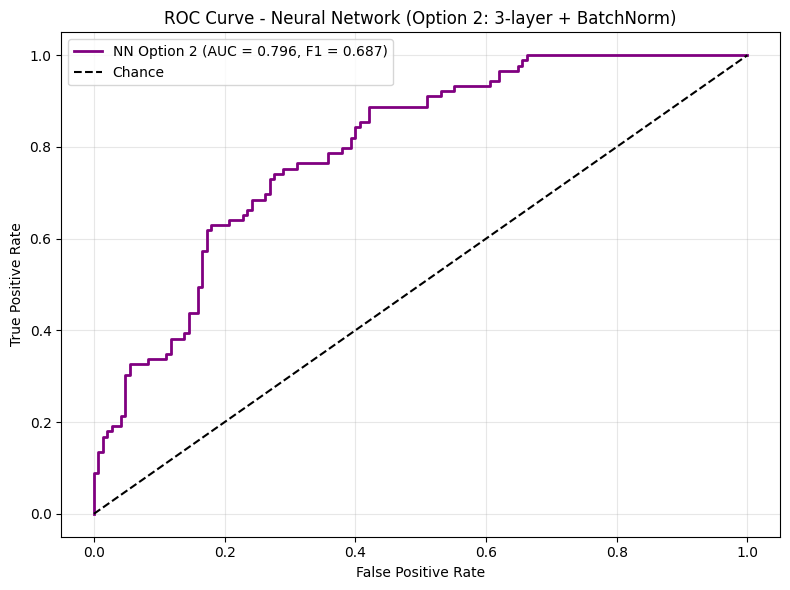

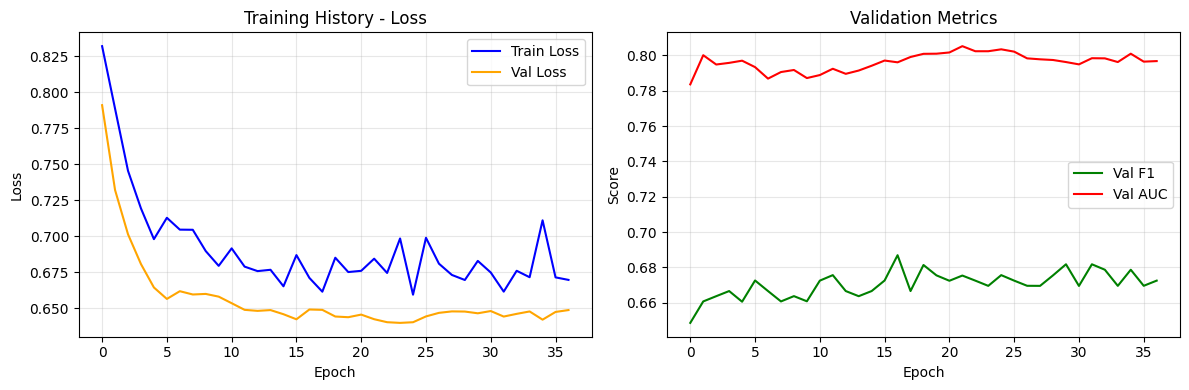

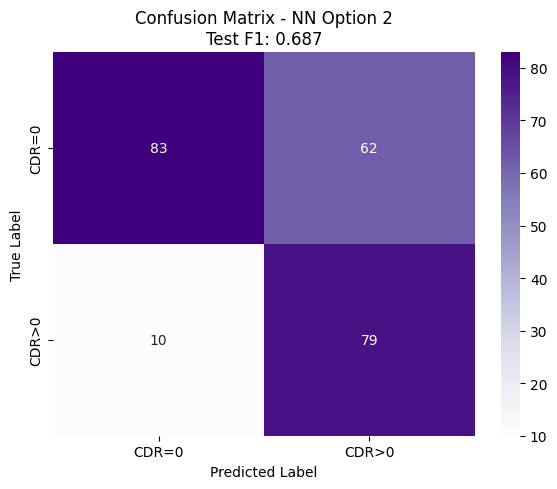

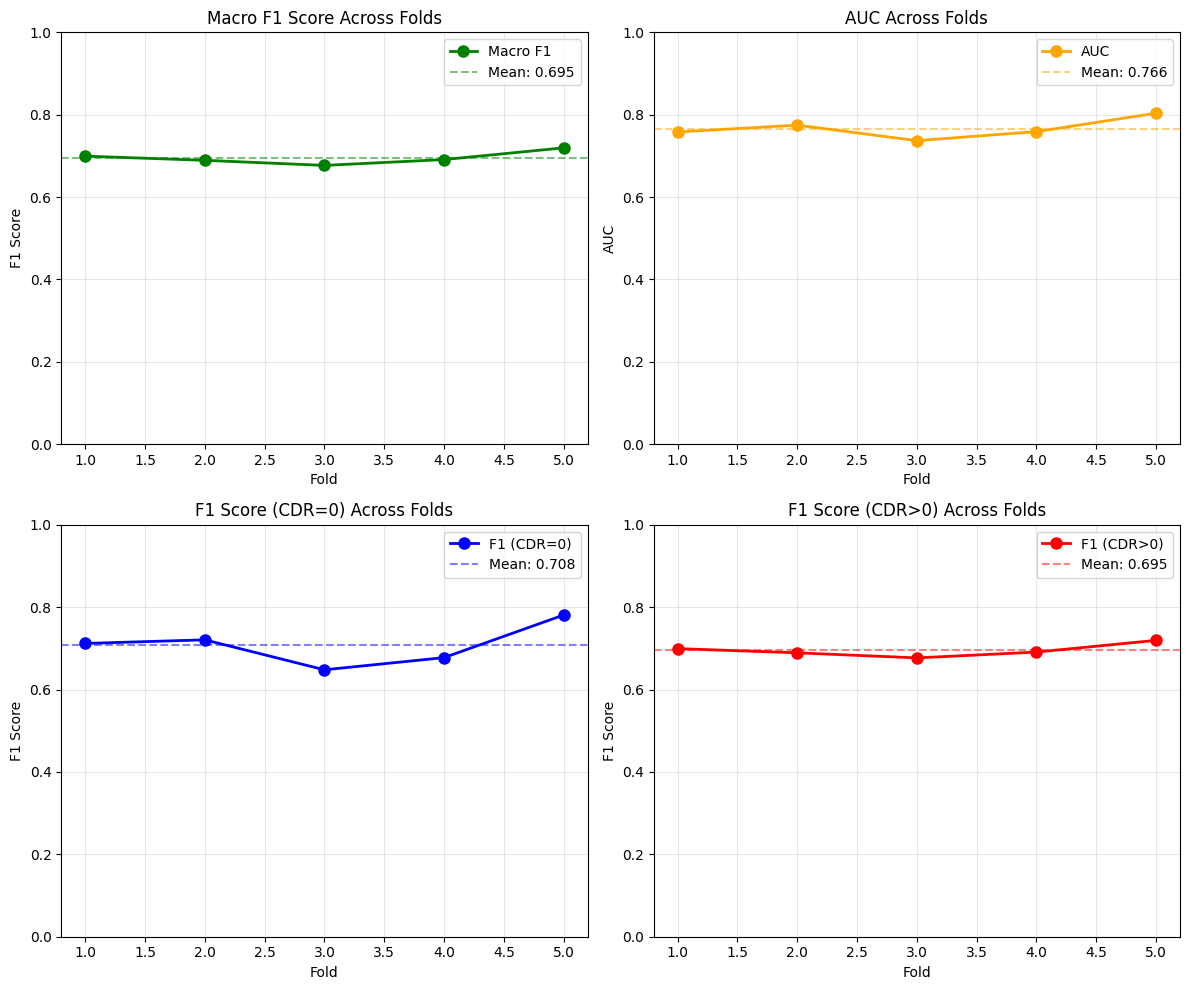


SUMMARY: CROSS-VALIDATION vs TEST SET
Metric                    CV (Mean ± Std)           Test Set       
----------------------------------------------------------------------
Accuracy                  0.703 ± 0.030           0.692
Macro F1                  0.695 ± 0.014           0.687
AUC-ROC                   0.766 ± 0.022           0.796
F1 (CDR=0)                0.708 ± 0.045           0.697
F1 (CDR>0)                0.695 ± 0.014           0.687

✓ Results loaded and visualized successfully!

Architecture: Option 2: 3-layer with BatchNorm (128→64→32)
This is a deeper 3-layer network with BatchNorm for better gradient flow


In [19]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve

print("Loading Neural Network results (Option 2: 3-layer + BatchNorm)...")

# Load results
with open('nn_results_option2.pkl', 'rb') as f:
    results = pickle.load(f)

# Extract results
nested_cv = results['nested_cv']
test_set = results['test_set']
final_params = results['final_params']
final_history = results['final_history']

# --- Display Architecture Info ---
print("\n" + "="*70)
print("ARCHITECTURE")
print("="*70)
print(f"{results['architecture']}")
print(f"Device used: {results['device_used']}")

# --- Display Nested CV Summary ---
print("\n" + "="*70)
print("NESTED CV SUMMARY (Outer Folds)")
print("="*70)
print(f"Mean F1 (Macro): {np.mean(nested_cv['f1_scores']):.3f} ± {np.std(nested_cv['f1_scores']):.3f}")
print(f"F1 per fold: {[f'{s:.3f}' for s in nested_cv['f1_scores']]}")
print(f"\nMean AUC: {np.mean(nested_cv['auc_scores']):.3f} ± {np.std(nested_cv['auc_scores']):.3f}")
print(f"AUC per fold: {[f'{s:.3f}' for s in nested_cv['auc_scores']]}")
print(f"\nMean Accuracy: {np.mean(nested_cv['acc_scores']):.3f} ± {np.std(nested_cv['acc_scores']):.3f}")
print(f"Accuracy per fold: {[f'{s:.3f}' for s in nested_cv['acc_scores']]}")

# --- Per-Fold Class-Specific F1 Scores ---
print("\n" + "="*70)
print("PER-FOLD CLASS-SPECIFIC METRICS")
print("="*70)

from sklearn.metrics import f1_score

fold_f1_cdr0 = []
fold_f1_cdr_pos = []

for i, fold_pred in enumerate(nested_cv['fold_predictions'], 1):
    y_true = fold_pred['y_true']
    y_pred = fold_pred['y_pred']
    
    # F1 for each class
    f1_cdr0 = f1_score(y_true, y_pred, pos_label=0, zero_division=0)
    f1_cdr_pos = f1_score(y_true, y_pred, pos_label=1, zero_division=0)
    
    fold_f1_cdr0.append(f1_cdr0)
    fold_f1_cdr_pos.append(f1_cdr_pos)
    
    print(f"Fold {i}:")
    print(f"  CDR=0 F1:  {f1_cdr0:.3f}")
    print(f"  CDR>0 F1:  {f1_cdr_pos:.3f}")

print(f"\nMean F1 (CDR=0):  {np.mean(fold_f1_cdr0):.3f} ± {np.std(fold_f1_cdr0):.3f}")
print(f"Mean F1 (CDR>0):  {np.mean(fold_f1_cdr_pos):.3f} ± {np.std(fold_f1_cdr_pos):.3f}")

# --- Display Test Set Results ---
print("\n" + "="*70)
print("TEST SET PERFORMANCE")
print("="*70)
print(f"Accuracy: {test_set['accuracy']:.3f}")
print(f"F1 Score (Macro): {test_set['f1']:.3f}")
print(f"AUC-ROC: {test_set['auc']:.3f}")

print(f"\nDetailed Classification Report:")
print(f"{'Class':<20} {'Precision':<12} {'Recall':<12} {'F1-Score':<12} {'Support':<10}")
print("-" * 70)
for label, metrics in test_set['classification_report'].items():
    if isinstance(metrics, dict) and label not in ['accuracy', 'macro avg', 'weighted avg']:
        support = metrics.get('support', 0)
        print(f"{label:<20} {metrics['precision']:<12.3f} {metrics['recall']:<12.3f} {metrics['f1-score']:<12.3f} {support:<10.0f}")

print("-" * 70)
# Display averages
if 'macro avg' in test_set['classification_report']:
    macro = test_set['classification_report']['macro avg']
    print(f"{'Macro avg':<20} {macro['precision']:<12.3f} {macro['recall']:<12.3f} {macro['f1-score']:<12.3f}")
if 'weighted avg' in test_set['classification_report']:
    weighted = test_set['classification_report']['weighted avg']
    print(f"{'Weighted avg':<20} {weighted['precision']:<12.3f} {weighted['recall']:<12.3f} {weighted['f1-score']:<12.3f}")

# --- Class-specific F1 on Test Set ---
print("\n" + "="*70)
print("TEST SET - CLASS-SPECIFIC F1 SCORES")
print("="*70)

test_f1_cdr0 = f1_score(test_set['y_true'], test_set['y_pred'], pos_label=0, zero_division=0)
test_f1_cdr_pos = f1_score(test_set['y_true'], test_set['y_pred'], pos_label=1, zero_division=0)

print(f"F1 (CDR=0):  {test_f1_cdr0:.3f}")
print(f"F1 (CDR>0):  {test_f1_cdr_pos:.3f}")
print(f"F1 (Macro):  {test_set['f1']:.3f}")

print(f"\nConfusion Matrix:")
print(np.array(test_set['confusion_matrix']))

print(f"\nBest hyperparameters: {final_params}")
print(f"Runtime: {results['runtime_minutes']:.1f} minutes")

# --- ROC Curve ---
fpr, tpr, _ = roc_curve(test_set['y_true'], test_set['y_prob'])
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"NN Option 2 (AUC = {test_set['auc']:.3f}, F1 = {test_set['f1']:.3f})", linewidth=2, color='purple')
plt.plot([0, 1], [0, 1], 'k--', label='Chance')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Neural Network (Option 2: 3-layer + BatchNorm)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# --- Training History ---
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(final_history['train_loss'], label='Train Loss', color='blue')
plt.plot(final_history['val_loss'], label='Val Loss', color='orange')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training History - Loss')
plt.legend()
plt.grid(alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(final_history['val_f1'], label='Val F1', color='green')
plt.plot(final_history['val_auc'], label='Val AUC', color='red')
plt.xlabel('Epoch')
plt.ylabel('Score')
plt.title('Validation Metrics')
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# --- Confusion Matrix Heatmap ---
cm = np.array(test_set['confusion_matrix'])
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', 
            xticklabels=['CDR=0', 'CDR>0'], 
            yticklabels=['CDR=0', 'CDR>0'])
plt.title(f"Confusion Matrix - NN Option 2\nTest F1: {test_set['f1']:.3f}")
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

# --- Fold-by-fold performance ---
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
folds = range(1, 6)

# F1 scores
axes[0, 0].plot(folds, nested_cv['f1_scores'], 'o-', label='Macro F1', color='green', linewidth=2, markersize=8)
axes[0, 0].axhline(y=np.mean(nested_cv['f1_scores']), color='green', linestyle='--', alpha=0.5, label=f'Mean: {np.mean(nested_cv["f1_scores"]):.3f}')
axes[0, 0].set_xlabel('Fold')
axes[0, 0].set_ylabel('F1 Score')
axes[0, 0].set_title('Macro F1 Score Across Folds')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)
axes[0, 0].set_ylim([0, 1])

# AUC scores
axes[0, 1].plot(folds, nested_cv['auc_scores'], 'o-', label='AUC', color='orange', linewidth=2, markersize=8)
axes[0, 1].axhline(y=np.mean(nested_cv['auc_scores']), color='orange', linestyle='--', alpha=0.5, label=f'Mean: {np.mean(nested_cv["auc_scores"]):.3f}')
axes[0, 1].set_xlabel('Fold')
axes[0, 1].set_ylabel('AUC')
axes[0, 1].set_title('AUC Across Folds')
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)
axes[0, 1].set_ylim([0, 1])

# Class-specific F1 - CDR=0
axes[1, 0].plot(folds, fold_f1_cdr0, 'o-', label='F1 (CDR=0)', color='blue', linewidth=2, markersize=8)
axes[1, 0].axhline(y=np.mean(fold_f1_cdr0), color='blue', linestyle='--', alpha=0.5, label=f'Mean: {np.mean(fold_f1_cdr0):.3f}')
axes[1, 0].set_xlabel('Fold')
axes[1, 0].set_ylabel('F1 Score')
axes[1, 0].set_title('F1 Score (CDR=0) Across Folds')
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)
axes[1, 0].set_ylim([0, 1])

# Class-specific F1 - CDR>0
axes[1, 1].plot(folds, fold_f1_cdr_pos, 'o-', label='F1 (CDR>0)', color='red', linewidth=2, markersize=8)
axes[1, 1].axhline(y=np.mean(fold_f1_cdr_pos), color='red', linestyle='--', alpha=0.5, label=f'Mean: {np.mean(fold_f1_cdr_pos):.3f}')
axes[1, 1].set_xlabel('Fold')
axes[1, 1].set_ylabel('F1 Score')
axes[1, 1].set_title('F1 Score (CDR>0) Across Folds')
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)
axes[1, 1].set_ylim([0, 1])

plt.tight_layout()
plt.show()

# --- Summary Comparison Table ---
print("\n" + "="*70)
print("SUMMARY: CROSS-VALIDATION vs TEST SET")
print("="*70)
print(f"{'Metric':<25} {'CV (Mean ± Std)':<25} {'Test Set':<15}")
print("-" * 70)
print(f"{'Accuracy':<25} {np.mean(nested_cv['acc_scores']):.3f} ± {np.std(nested_cv['acc_scores']):.3f}           {test_set['accuracy']:.3f}")
print(f"{'Macro F1':<25} {np.mean(nested_cv['f1_scores']):.3f} ± {np.std(nested_cv['f1_scores']):.3f}           {test_set['f1']:.3f}")
print(f"{'AUC-ROC':<25} {np.mean(nested_cv['auc_scores']):.3f} ± {np.std(nested_cv['auc_scores']):.3f}           {test_set['auc']:.3f}")
print(f"{'F1 (CDR=0)':<25} {np.mean(fold_f1_cdr0):.3f} ± {np.std(fold_f1_cdr0):.3f}           {test_f1_cdr0:.3f}")
print(f"{'F1 (CDR>0)':<25} {np.mean(fold_f1_cdr_pos):.3f} ± {np.std(fold_f1_cdr_pos):.3f}           {test_f1_cdr_pos:.3f}")
print("="*70)

print("\n✓ Results loaded and visualized successfully!")
print(f"\nArchitecture: {results['architecture']}")
print(f"This is a deeper 3-layer network with BatchNorm for better gradient flow")

### Final Option
`python train_nn_final.py`


Loading results...


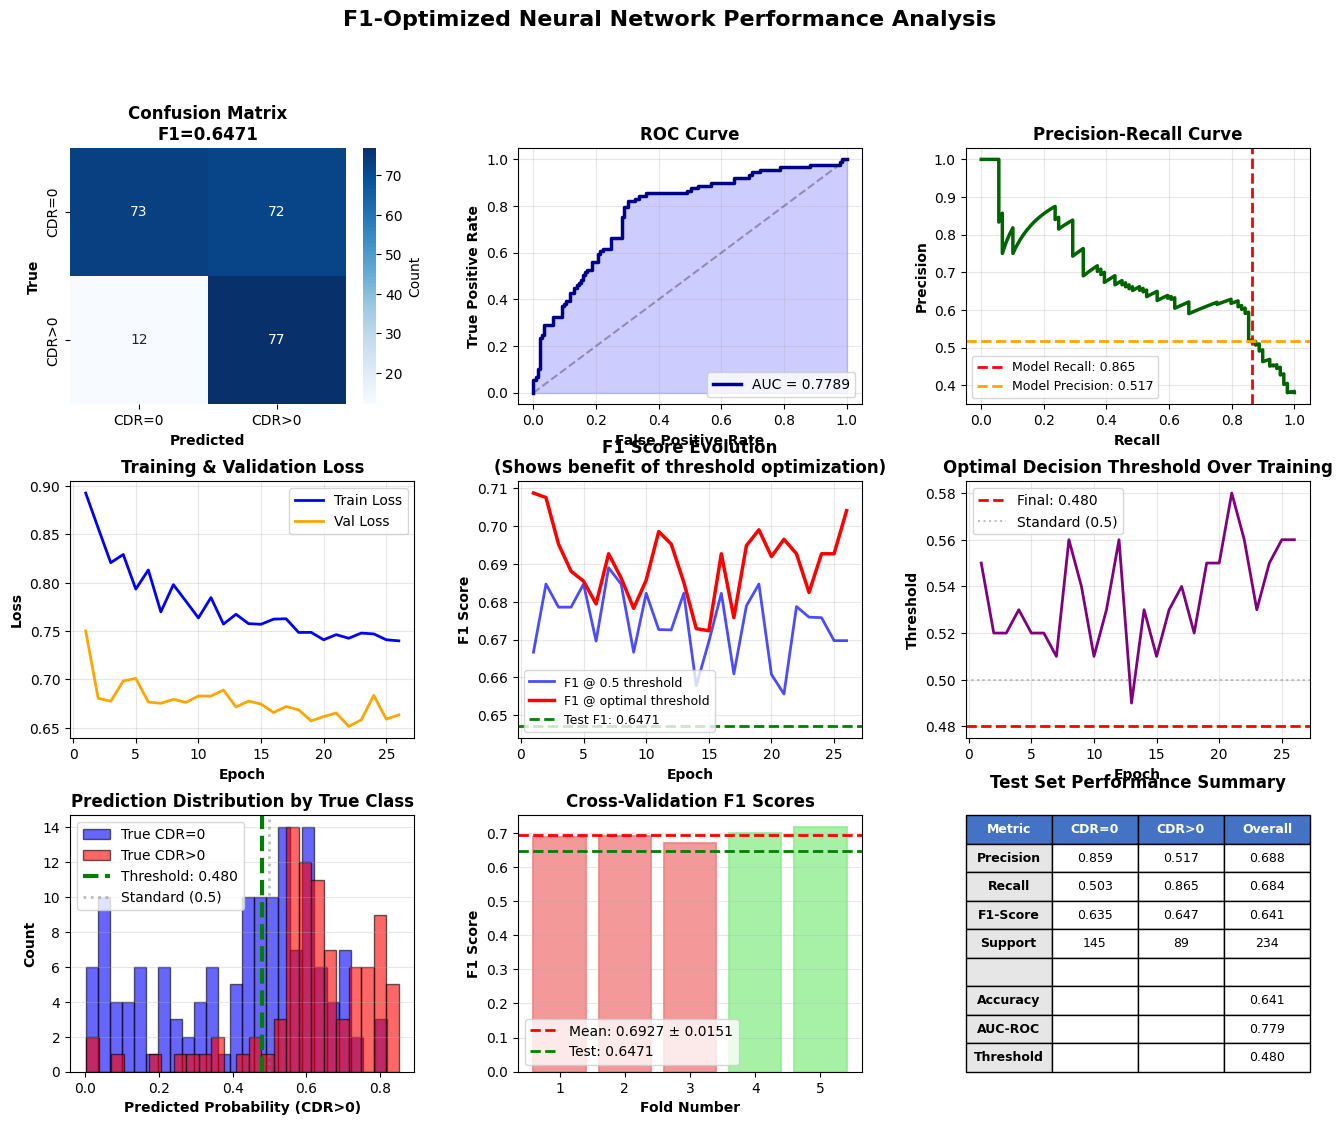


MODEL PERFORMANCE SUMMARY
Test F1 Score:       0.6471
Test AUC:            0.7789
Test Accuracy:       0.6410
Optimal Threshold:   0.480

CV F1 Score:         0.6927 ± 0.0151
CV AUC Score:        0.7681 ± 0.0126

Per-Class Performance (CDR>0 - Dementia):
  Precision: 0.5168
  Recall:    0.8652
  F1-Score:  0.6471


In [21]:
import pickle
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import roc_curve, precision_recall_curve

print("Loading results...")
with open('nn_results_f1_optimized.pkl', 'rb') as f:
    results = pickle.load(f)

# Create comprehensive visualization
fig = plt.figure(figsize=(16, 12))
gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)

# ============================================================================
# 1. CONFUSION MATRIX
# ============================================================================
ax1 = fig.add_subplot(gs[0, 0])
cm = np.array(results['test_set']['confusion_matrix'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax1,
            xticklabels=['CDR=0', 'CDR>0'], 
            yticklabels=['CDR=0', 'CDR>0'],
            cbar_kws={'label': 'Count'})
ax1.set_xlabel('Predicted', fontweight='bold')
ax1.set_ylabel('True', fontweight='bold')
ax1.set_title(f"Confusion Matrix\nF1={results['test_set']['f1']:.4f}", 
              fontweight='bold', fontsize=12)

# ============================================================================
# 2. ROC CURVE
# ============================================================================
ax2 = fig.add_subplot(gs[0, 1])
y_true = results['test_set']['y_true']
y_prob = results['test_set']['y_prob']
fpr, tpr, _ = roc_curve(y_true, y_prob)
auc = results['test_set']['auc']

ax2.plot(fpr, tpr, linewidth=2.5, label=f'AUC = {auc:.4f}', color='darkblue')
ax2.plot([0, 1], [0, 1], 'k--', alpha=0.3, linewidth=1.5)
ax2.fill_between(fpr, tpr, alpha=0.2, color='blue')
ax2.set_xlabel('False Positive Rate', fontweight='bold')
ax2.set_ylabel('True Positive Rate', fontweight='bold')
ax2.set_title('ROC Curve', fontweight='bold', fontsize=12)
ax2.legend(loc='lower right', fontsize=10)
ax2.grid(True, alpha=0.3)

# ============================================================================
# 3. PRECISION-RECALL CURVE
# ============================================================================
ax3 = fig.add_subplot(gs[0, 2])
precision, recall, thresholds_pr = precision_recall_curve(y_true, y_prob)
ax3.plot(recall, precision, linewidth=2.5, color='darkgreen')
ax3.axvline(results['test_set']['classification_report']['CDR>0']['recall'], 
            color='red', linestyle='--', linewidth=2, 
            label=f"Model Recall: {results['test_set']['classification_report']['CDR>0']['recall']:.3f}")
ax3.axhline(results['test_set']['classification_report']['CDR>0']['precision'], 
            color='orange', linestyle='--', linewidth=2,
            label=f"Model Precision: {results['test_set']['classification_report']['CDR>0']['precision']:.3f}")
ax3.set_xlabel('Recall', fontweight='bold')
ax3.set_ylabel('Precision', fontweight='bold')
ax3.set_title('Precision-Recall Curve', fontweight='bold', fontsize=12)
ax3.legend(loc='best', fontsize=9)
ax3.grid(True, alpha=0.3)

# ============================================================================
# 4. TRAINING & VALIDATION LOSS
# ============================================================================
ax4 = fig.add_subplot(gs[1, 0])
history = results['final_history']
epochs = range(1, len(history['train_loss']) + 1)
ax4.plot(epochs, history['train_loss'], label='Train Loss', linewidth=2, color='blue')
ax4.plot(epochs, history['val_loss'], label='Val Loss', linewidth=2, color='orange')
ax4.set_xlabel('Epoch', fontweight='bold')
ax4.set_ylabel('Loss', fontweight='bold')
ax4.set_title('Training & Validation Loss', fontweight='bold', fontsize=12)
ax4.legend()
ax4.grid(True, alpha=0.3)

# ============================================================================
# 5. F1 SCORE OVER TRAINING (Standard vs Optimized)
# ============================================================================
ax5 = fig.add_subplot(gs[1, 1])
ax5.plot(epochs, history['val_f1'], label='F1 @ 0.5 threshold', 
         linewidth=2, color='blue', alpha=0.7)
ax5.plot(epochs, history['val_f1_optimized'], label='F1 @ optimal threshold', 
         linewidth=2.5, color='red')
ax5.axhline(results['test_set']['f1'], color='green', linestyle='--', 
            linewidth=2, label=f"Test F1: {results['test_set']['f1']:.4f}")
ax5.set_xlabel('Epoch', fontweight='bold')
ax5.set_ylabel('F1 Score', fontweight='bold')
ax5.set_title('F1 Score Evolution\n(Shows benefit of threshold optimization)', 
              fontweight='bold', fontsize=12)
ax5.legend(fontsize=9)
ax5.grid(True, alpha=0.3)

# ============================================================================
# 6. OPTIMAL THRESHOLD OVER TRAINING
# ============================================================================
ax6 = fig.add_subplot(gs[1, 2])
ax6.plot(epochs, history['optimal_thresholds'], linewidth=2, color='purple')
ax6.axhline(results['test_set']['optimal_threshold'], color='red', 
            linestyle='--', linewidth=2,
            label=f"Final: {results['test_set']['optimal_threshold']:.3f}")
ax6.axhline(0.5, color='gray', linestyle=':', linewidth=1.5, 
            label='Standard (0.5)', alpha=0.5)
ax6.set_xlabel('Epoch', fontweight='bold')
ax6.set_ylabel('Threshold', fontweight='bold')
ax6.set_title('Optimal Decision Threshold Over Training', 
              fontweight='bold', fontsize=12)
ax6.legend()
ax6.grid(True, alpha=0.3)

# ============================================================================
# 7. PREDICTION DISTRIBUTION
# ============================================================================
ax7 = fig.add_subplot(gs[2, 0])
y_pred = results['test_set']['y_pred']
probs_class0 = y_prob[y_true == 0]
probs_class1 = y_prob[y_true == 1]

ax7.hist(probs_class0, bins=25, alpha=0.6, label='True CDR=0', 
         color='blue', edgecolor='black')
ax7.hist(probs_class1, bins=25, alpha=0.6, label='True CDR>0', 
         color='red', edgecolor='black')
ax7.axvline(results['test_set']['optimal_threshold'], color='green', 
            linestyle='--', linewidth=3,
            label=f"Threshold: {results['test_set']['optimal_threshold']:.3f}")
ax7.axvline(0.5, color='gray', linestyle=':', linewidth=2, 
            label='Standard (0.5)', alpha=0.5)
ax7.set_xlabel('Predicted Probability (CDR>0)', fontweight='bold')
ax7.set_ylabel('Count', fontweight='bold')
ax7.set_title('Prediction Distribution by True Class', fontweight='bold', fontsize=12)
ax7.legend()
ax7.grid(True, alpha=0.3, axis='y')

# ============================================================================
# 8. CROSS-VALIDATION F1 SCORES
# ============================================================================
ax8 = fig.add_subplot(gs[2, 1])
cv_f1_scores = results['nested_cv']['f1_scores']
fold_numbers = range(1, len(cv_f1_scores) + 1)
mean_cv_f1 = np.mean(cv_f1_scores)
std_cv_f1 = np.std(cv_f1_scores)

bars = ax8.bar(fold_numbers, cv_f1_scores, color='skyblue', 
               edgecolor='black', linewidth=1.5, alpha=0.8)
ax8.axhline(mean_cv_f1, color='red', linestyle='--', linewidth=2,
            label=f'Mean: {mean_cv_f1:.4f} ± {std_cv_f1:.4f}')
ax8.axhline(results['test_set']['f1'], color='green', linestyle='--', 
            linewidth=2, label=f"Test: {results['test_set']['f1']:.4f}")

# Color the bars based on performance
for i, (bar, score) in enumerate(zip(bars, cv_f1_scores)):
    if score >= mean_cv_f1:
        bar.set_color('lightgreen')
    else:
        bar.set_color('lightcoral')

ax8.set_xlabel('Fold Number', fontweight='bold')
ax8.set_ylabel('F1 Score', fontweight='bold')
ax8.set_title('Cross-Validation F1 Scores', fontweight='bold', fontsize=12)
ax8.set_xticks(fold_numbers)
ax8.legend()
ax8.grid(True, alpha=0.3, axis='y')

# ============================================================================
# 9. METRICS SUMMARY TABLE
# ============================================================================
ax9 = fig.add_subplot(gs[2, 2])
ax9.axis('off')

# Gather metrics
test_report = results['test_set']['classification_report']
metrics_data = [
    ['Metric', 'CDR=0', 'CDR>0', 'Overall'],
    ['Precision', f"{test_report['CDR=0']['precision']:.3f}", 
     f"{test_report['CDR>0']['precision']:.3f}", 
     f"{test_report['macro avg']['precision']:.3f}"],
    ['Recall', f"{test_report['CDR=0']['recall']:.3f}", 
     f"{test_report['CDR>0']['recall']:.3f}", 
     f"{test_report['macro avg']['recall']:.3f}"],
    ['F1-Score', f"{test_report['CDR=0']['f1-score']:.3f}", 
     f"{test_report['CDR>0']['f1-score']:.3f}", 
     f"{test_report['macro avg']['f1-score']:.3f}"],
    ['Support', f"{int(test_report['CDR=0']['support'])}", 
     f"{int(test_report['CDR>0']['support'])}", 
     f"{int(test_report['macro avg']['support'])}"],
    ['', '', '', ''],
    ['Accuracy', '', '', f"{results['test_set']['accuracy']:.3f}"],
    ['AUC-ROC', '', '', f"{results['test_set']['auc']:.3f}"],
    ['Threshold', '', '', f"{results['test_set']['optimal_threshold']:.3f}"],
]

table = ax9.table(cellText=metrics_data, cellLoc='center', loc='center',
                  bbox=[0, 0, 1, 1])
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 2)

# Style the header row
for i in range(4):
    table[(0, i)].set_facecolor('#4472C4')
    table[(0, i)].set_text_props(weight='bold', color='white')

# Style metric names column
for i in range(1, len(metrics_data)):
    table[(i, 0)].set_facecolor('#E7E6E6')
    table[(i, 0)].set_text_props(weight='bold')

ax9.set_title('Test Set Performance Summary', fontweight='bold', 
              fontsize=12, pad=20)

# ============================================================================
# MAIN TITLE
# ============================================================================
fig.suptitle('F1-Optimized Neural Network Performance Analysis', 
             fontsize=16, fontweight='bold', y=0.995)

plt.show()

# ============================================================================
# PRINT SUMMARY
# ============================================================================
print("\n" + "="*70)
print("MODEL PERFORMANCE SUMMARY")
print("="*70)
print(f"Test F1 Score:       {results['test_set']['f1']:.4f}")
print(f"Test AUC:            {results['test_set']['auc']:.4f}")
print(f"Test Accuracy:       {results['test_set']['accuracy']:.4f}")
print(f"Optimal Threshold:   {results['test_set']['optimal_threshold']:.3f}")
print(f"\nCV F1 Score:         {np.mean(results['nested_cv']['f1_scores']):.4f} ± {np.std(results['nested_cv']['f1_scores']):.4f}")
print(f"CV AUC Score:        {np.mean(results['nested_cv']['auc_scores']):.4f} ± {np.std(results['nested_cv']['auc_scores']):.4f}")
print("\nPer-Class Performance (CDR>0 - Dementia):")
print(f"  Precision: {test_report['CDR>0']['precision']:.4f}")
print(f"  Recall:    {test_report['CDR>0']['recall']:.4f}")
print(f"  F1-Score:  {test_report['CDR>0']['f1-score']:.4f}")
print("="*70)

# EOF